# short codes 

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pmcx
from scipy.ndimage import zoom
import copy
import os
import argparse

def show_src_vol(src_pos,src_dir,vol):
    src_pos=src_pos.astype(int)
    # Extract the x, y, z planes at the source position
    x_pos, y_pos, z_pos = src_pos[0], src_pos[1], src_pos[2]
    x_plane = vol[x_pos, :, :]
    y_plane = vol[:, y_pos, :]
    z_plane = vol[:, :, z_pos]
    # Plotting in 3 axes
    plt.figure(figsize=(15, 5))
    # Plot for x-y plane
    plt.subplot(1, 3, 1)
    plt.imshow(x_plane.T, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(y_pos, z_pos, 'ro', markersize=10, label='Source')
    arrow_scale = 20
    arrow_y = y_pos + arrow_scale * src_dir[1]
    arrow_z = z_pos + arrow_scale * src_dir[2]
    plt.arrow(y_pos, z_pos, arrow_y - y_pos, arrow_z - z_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('y [voxels]')
    plt.ylabel('z [voxels]')
    plt.title('X-Y Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    # Plot for y-z plane
    plt.subplot(1, 3, 2)
    plt.imshow(y_plane, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(z_pos, x_pos, 'ro', markersize=10, label='Source')
    arrow_y = z_pos + arrow_scale * src_dir[2]
    arrow_x = x_pos + arrow_scale * src_dir[0]
    plt.arrow(z_pos, x_pos, arrow_y - z_pos, arrow_x - x_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('z [voxels]')
    plt.ylabel('x [voxels]')
    plt.title('Y-Z Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    # Plot for x-z plane
    plt.subplot(1, 3, 3)
    plt.imshow(z_plane.T, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(x_pos, y_pos, 'ro', markersize=10, label='Source')
    arrow_x = x_pos + arrow_scale * src_dir[0]
    arrow_y = y_pos + arrow_scale * src_dir[1]
    plt.arrow(x_pos, y_pos, arrow_x - x_pos, arrow_y - y_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('x [voxels]')
    plt.ylabel('y [voxels]')
    plt.title('X-Z Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()
def view_result(res,vol):
    CWfluence = np.sum(res['flux'], axis=3)
    #CWfluence*=mask
    old_vol=vol
    new_vol=old_vol#*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()
def view_result_mask(res,vol,mask):
    CWfluence = np.sum(res['flux'], axis=3)
    CWfluence*=mask
    old_vol=vol
    new_vol=old_vol*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()
def from_csv_get_subject_coord(subject_csv,region_name):
    import pandas as pd
    df=pd.read_csv(subject_csv,header=None)
    x,y,z=df[df[4]==region_name].values[0][1:4]
    return np.array([x,y,z])
def run_fn(inputs_dict):
    path,subject_csv,seg_path,region_name,src_dir_mode=inputs_dict["path"],inputs_dict["subject_csv"],inputs_dict["seg_path"],inputs_dict["region_name"],inputs_dict["src_dir_mode"]
    Fpz_subject=from_csv_get_subject_coord(subject_csv,region_name)
    print(inputs_dict,Fpz_subject)
    img = nib.load(path)
    vol=img.get_fdata()[...,0].astype('uint8')

    affine_matrix = img.affine
    print(affine_matrix.shape)
    image_coord = np.linalg.inv(affine_matrix) @ np.append(Fpz_subject, 1)
    src_pos = image_coord[:3]
    print("numpy space",src_pos,vol.shape)
    #src_pos = src_pos * pixdim[:3]
    pixdim = img.header.get_zooms()
    zoom_factor=np.array(pixdim[:3]) / np.array([1.0, 1.0, 1.0])
    vol = zoom(vol, zoom_factor, order=0)
    src_pos = src_pos*zoom_factor
    print("real spcae",src_pos,vol.shape,set(vol.flatten()))
    
    src_dir = None
    target_position = None
    if src_dir_mode=="fixed": # min distance(src_pos) # target(src_pos,tar_pos)
        src_dir=np.array([1.,0.,0.])
        print("using fixed direction, ",src_dir)
    elif src_dir_mode=="default":
        print("using default mode, ignoring seg_path")
        cortex_coords = np.argwhere(np.logical_or(vol==1,vol==2))
        distances = np.linalg.norm(cortex_coords - src_pos, axis=1)
        num_top_points = int(len(distances) * 0.05)
        top_indices = np.argsort(distances)[:num_top_points]
        top_coords = cortex_coords[top_indices]
        target_position = np.mean(top_coords, axis=0)
        direction = target_position - src_pos
        normed_direction = direction / np.linalg.norm(direction)
        src_dir=normed_direction
        print("tar_pos real space",target_position)
        # temp_vol=copy.deepcopy(vol).astype(np.float64)
        # temp_vol[top_indices]=np.nan
        show_src_vol(target_position,-src_dir,vol)
    elif src_dir_mode=="target":
        seg_img=nib.load(seg_path)
        seg_vol=seg_img.get_fdata()
        seg_pixdim = seg_img.header.get_zooms()
        seg_zoom_factor=np.array(seg_pixdim[:3]) / np.array([1.0, 1.0, 1.0])
        seg_vol = zoom(seg_vol, seg_zoom_factor, order=0)
        cortex_coords=np.argwhere(seg_vol==17)# Right # 53.5Left
        top_coords = cortex_coords#[top_indices]
        target_position = np.mean(top_coords, axis=0)
        direction = target_position - src_pos
        normed_direction = direction / np.linalg.norm(direction)
        src_dir=normed_direction
        print("tar_pos real space",target_position)
        print("tar_pos numpy space", target_position/seg_zoom_factor)
        # temp_vol=copy.deepcopy(vol).astype(np.float64)
        # temp_vol[top_coords]=np.nan
        show_src_vol(target_position,-src_dir,vol)
    
    show_src_vol(src_pos,src_dir,vol)
    #show_src_vol(target_position,src_dir,vol)
    
    print(src_pos,src_dir,vol.shape)
    return {"src_pos":src_pos,"src_dir":src_dir,"vol":vol,"target_position":target_position}

def run_fn_stage2(input_dict_v2):
    vol = input_dict_v2["vol"]
    src_dir=input_dict_v2["src_dir"]
    src_pos=input_dict_v2["src_pos"]
    stage_2_mode=input_dict_v2["stage_2_mode"]
    custom_src=input_dict_v2["custom_src"]
    save_path=input_dict_v2["save_path"]
    p=input_dict_v2["p"]
    t=input_dict_v2["t"]
    # custom_src={
    #     "srctype":"disk",
    #     "srcparam1":[12,0,0,0],
    #     "srcparam2":[0,0,0,0],
    # }

    import pmcx
    import nibabel
    import numpy as np
    import nibabel as nib
    import matplotlib.pyplot as plt
    import scipy.io as sio
    import pmcx
    
    ambient_air = np.zeros_like(vol)
    individual_atlas=np.zeros_like(vol)
    # map scalp,csf,gm,wm,air to 1,2,3,4 and rest to 0
    # prop=[
    #   [0, 0, 1, 1], # air
    #   [0.092,38,0.89,1.37], # WM
    #   [0.028,7.3,0.89,1.37], # GM
    #   [0.0026,0.091,0.89,1.37],# CSF
    #   [0,0,1,1], # #4 things
    #   [0.0168,17.82,0.89,1.37],# Scalp
    #   [0,0,1,1],# Eye_balss assuming as air
    #   [0.011,17.82,0.89,1.37],# Compact_bone
    #   [0.011,17.82,0.89,1.37],# Spongy_bone
    #   [0,0,1,1],# Blood assuming as air
    #   [0,0,1,1],# Muscle assuming as air
    # ]
    individual_atlas[vol >0] = 1 # as scalp
    individual_atlas[vol == 5] = 1 # scalp
    individual_atlas[vol == 7] = 2 # skull
    individual_atlas[vol == 8] = 2 # skull
    individual_atlas[vol == 3] = 3 # csf
    individual_atlas[vol == 2] = 4 # gm
    individual_atlas[vol == 1] = 5 # wm 
    individual_atlas[vol >5] = 1 # air 
    
    # Light parameters
    length = 1064
    d = 1
    #p = 250 # 辐照度 mW/
    #t = 8 # mins
    timwin = 1e-9
    
    light_parameter = np.array([
        [0, 0, 1, 1],# air
        [0.017, 18.45, 0.89, 1.37],# scalp
        [0.019, 14.6, 0.89, 1.37],# skull 
        [0.0144, 0.09, 0.89, 1.37],# csf
        [0.053, 5.9, 0.91, 1.37],#gm
        [0.105, 30, 0.88, 1.37],# wm
        #[0.033,9.35,0.89,1.37], # ECT
        [0.105,30,0.88,1.37] # air cavities
    ])
    def power2photon(d, p, t, length):
        h = 6.62607015e-34  # Planck constant
        c = 3e8  # Speed of light
        E = (h * c) / (length * 1e-9)  # Energy per photon
        N = (p * d * t) / E  # Number of photons
        return N
    N = power2photon(d, p, t, length)
    
    cfg = {
        'nphoton': timwin * N / (t * 60),
        'outputtype': 'energy',
        'vol': individual_atlas,
        'prop': light_parameter[[0, 1, 2, 3, 4,5], :].tolist(),
        'srcnum': 1,
        'srcpos': src_pos,#f3_subject_pos,#[100, 175, 215.0700],
        'srctype': 'pencil',
        'srcdir': src_dir,#[-0.5086, -0.1822, -0.8415],
        'issrcfrom0': 1,
        'tstart': 0,
        'tend': timwin,
        'tstep': timwin,
        'isspecular': 0,
        'isreflect': 1,
        'autopilot': 1,
        'gpuid': 1
    }
    if custom_src!=None:
        cfg.update(custom_src) 
    if stage_2_mode=="simple":
        cfg["nphoton"]=1e6

    
    print(cfg)
    # check source 
    show_src_vol(cfg["srcpos"],cfg["srcdir"],cfg["vol"])
    print(cfg["srcpos"],cfg["srcdir"],cfg["vol"].shape)
    
    # Run MCX simulation
    res = pmcx.mcxlab(cfg)
    flux = res['flux']
    
    view_result(res,cfg["vol"])
    view_result_mask(res,cfg["vol"],cfg["vol"]>2)
    
    original_img=nib.load(input_dict["path"])
    original_affine = original_img.affine
    original_pixdim = original_img.header.get_zooms()
    flux_pixdim = np.ones_like(original_pixdim)  # Voxel dimensions for flux data
    zoom_factors = flux_pixdim / original_pixdim
    resized_flux = zoom(flux, zoom_factors, order=1)  # Use order=1 for linear interpolation
    resized_flux = resized_flux.astype(np.float32)
    resized_flux[resized_flux<1e-10]=1e-10
    resized_flux=np.log10(resized_flux)
    nii_image = nib.Nifti1Image(resized_flux, original_affine)
    if not os.path.exists(save_path): os.makedirs(save_path)
    np.save(os.path.join(save_path,"MCX_outputs"),input_dict_v2)
    nib.save(nii_image, os.path.join(save_path,"MCX_results_log.nii.gz"))
    nib.save(original_img,os.path.join(save_path,"MCX_input_vol.nii.gz"))
    print(f"MCX results saved to {save_path}")
    return {"res":res,"flux":flux,"resized_flux":resized_flux,"output_path":save_path}

{'path': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\final_tissues.nii.gz', 'subject_csv': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\eeg_positions\\EEG10-10_UI_Jurak_2007.csv', 'seg_path': None, 'region_name': 'Fp1', 'src_dir_mode': 'default'} [-26.82230898  85.13350658  45.12873188]
(4, 4)
numpy space [ 53.9082878  162.31852576  51.514784  ] (256, 256, 150)
real spcae [ 50.53901981 152.1736179   61.81758359] (240, 240, 180) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
using default mode, ignoring seg_path
tar_pos real space [ 81.88419057 149.01719652  72.51649866]


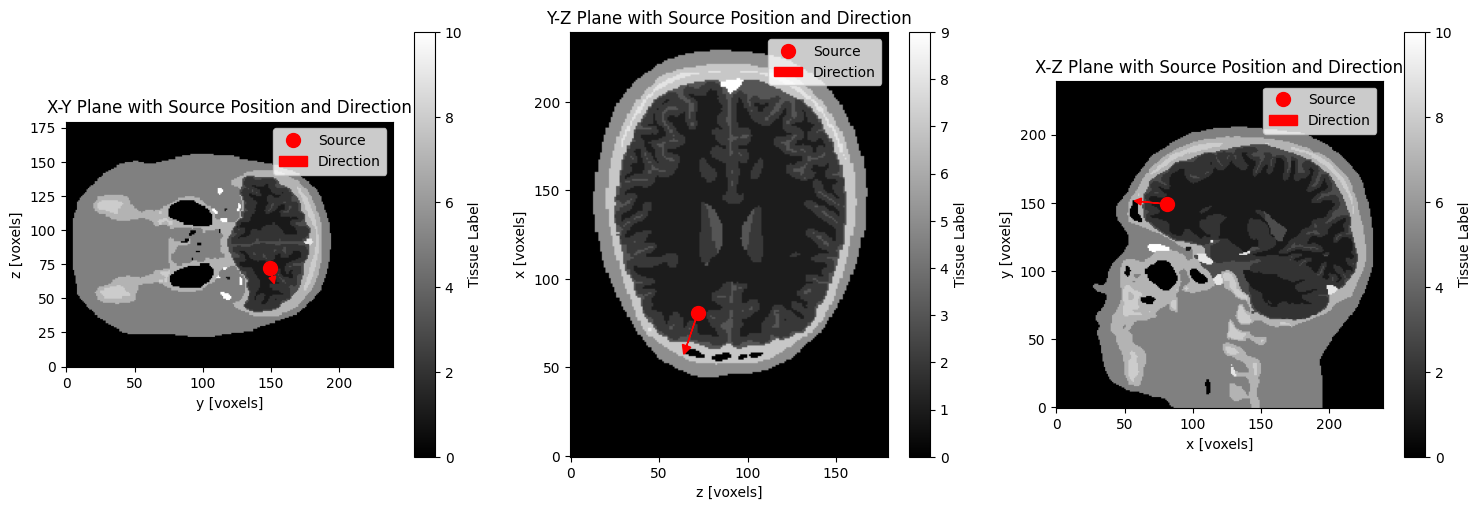

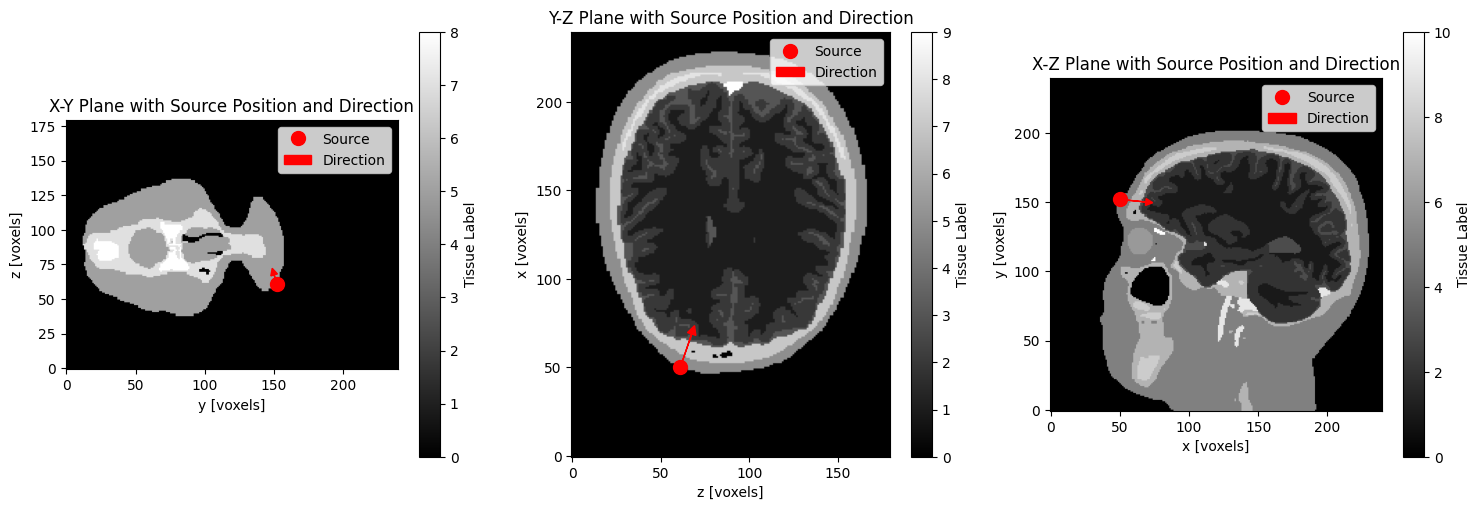

[ 50.53901981 152.1736179   61.81758359] [ 0.94212111 -0.09487047  0.32157023] (240, 240, 180)
{'nphoton': 1000000.0, 'outputtype': 'energy', 'vol': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ...

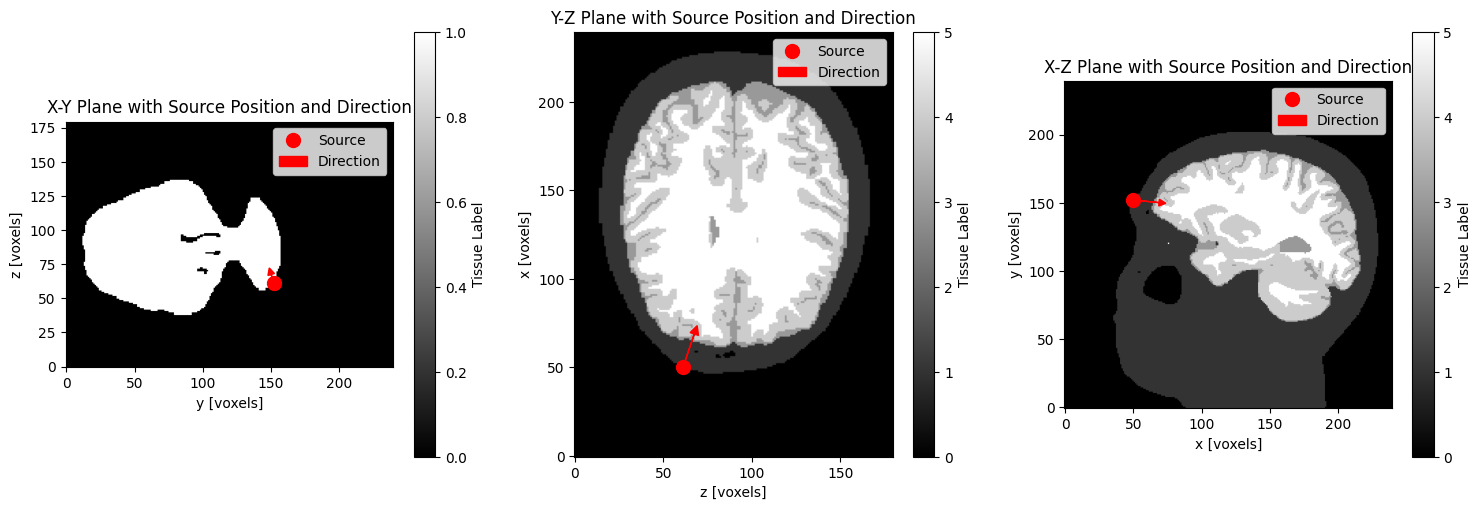

[ 50.53901981 152.1736179   61.81758359] [ 0.94212111 -0.09487047  0.32157023] (240, 240, 180)
nphoton: 1e+06
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:68: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:69: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:73: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:74: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:78: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol

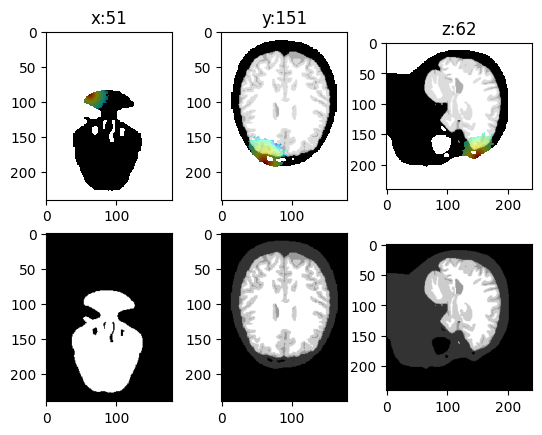

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:98: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:102: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:103: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_22144\1950443722.py:107: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_

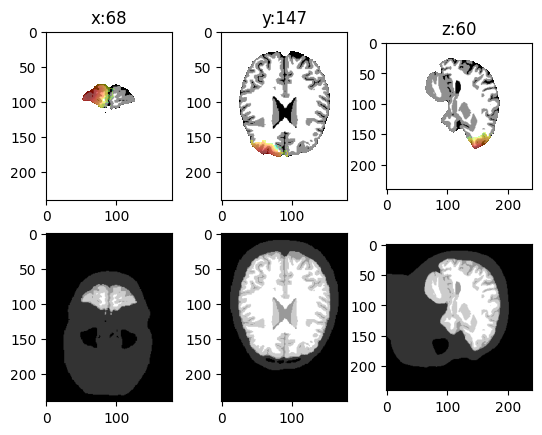

MCX results saved to C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\mcx_simulations


In [3]:
# inputs:
subject_path=r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828"
p=250
t=8
region_name="Fp1"
save_path=r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\mcx_simulations"

# def main():
#     parser = argparse.ArgumentParser(description='Run Monte Carlo simulation for photon transport in a head model.')
#     parser.add_argument('--subject_path', required=True, help='Path to the the head model folder .')
#     parser.add_argument('--save_path', required=True, help='Path to the output folder.')
#     parser.add_argument('--region_name', required=True, help='Region name in the CSV file to be used as source position.')
#     parser.add_argument('--p', type=float, required=True, help='Simulation parameter p.')
#     parser.add_argument('--t', type=float, required=True, help='Simulation parameter t.')

#     args = parser.parse_args()
#     subject_path=args.subject_path
#     p=args.p
#     t=args.t
#     region_name=args.region_name
#     save_path=args.save_path
    
input_dict={
    "path":os.path.join(subject_path,"final_tissues.nii.gz"), # subject 10 seg maps
    "subject_csv":os.path.join(subject_path,"eeg_positions","EEG10-10_UI_Jurak_2007.csv"), # subject EEG csv
    "seg_path":None,#r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz", # subejct ROI seg(here = hippo)
    "region_name":region_name, # subject region
    "src_dir_mode":"default", # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}
output_dict=run_fn(input_dict)
vol = output_dict["vol"]
src_dir=output_dict["src_dir"]
src_pos=output_dict["src_pos"]
output_dict["stage_2_mode"]="simple" # "simple" # 1e-6 instead of many photos
output_dict["custom_src"]=None # pass custom src setting or do nothing 
output_dict["save_path"]=save_path
output_dict["p"]=p
output_dict["t"]=t
output_dict_2=run_fn_stage2(output_dict)
#{"res":res,"flux":flux,"resized_flux":resized_flux,"output_path":output_path}



# Prepare

In [4]:
import skimage

In [8]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pmcx
from scipy.ndimage import zoom
import copy
def show_src_vol(src_pos,src_dir,vol):
    src_pos=src_pos.astype(int)
    # Extract the x, y, z planes at the source position
    x_pos, y_pos, z_pos = src_pos[0], src_pos[1], src_pos[2]
    x_plane = vol[x_pos, :, :]
    y_plane = vol[:, y_pos, :]
    z_plane = vol[:, :, z_pos]
    # Plotting in 3 axes
    plt.figure(figsize=(15, 5))
    # Plot for x-y plane
    plt.subplot(1, 3, 1)
    plt.imshow(x_plane.T, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(y_pos, z_pos, 'ro', markersize=10, label='Source')
    arrow_scale = 20
    arrow_y = y_pos + arrow_scale * src_dir[1]
    arrow_z = z_pos + arrow_scale * src_dir[2]
    plt.arrow(y_pos, z_pos, arrow_y - y_pos, arrow_z - z_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('y [voxels]')
    plt.ylabel('z [voxels]')
    plt.title('X-Y Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    # Plot for y-z plane
    plt.subplot(1, 3, 2)
    plt.imshow(y_plane, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(z_pos, x_pos, 'ro', markersize=10, label='Source')
    arrow_y = z_pos + arrow_scale * src_dir[2]
    arrow_x = x_pos + arrow_scale * src_dir[0]
    plt.arrow(z_pos, x_pos, arrow_y - z_pos, arrow_x - x_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('z [voxels]')
    plt.ylabel('x [voxels]')
    plt.title('Y-Z Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    # Plot for x-z plane
    plt.subplot(1, 3, 3)
    plt.imshow(z_plane.T, cmap='gray', origin='lower', aspect='equal')
    plt.colorbar(label='Tissue Label')
    plt.plot(x_pos, y_pos, 'ro', markersize=10, label='Source')
    arrow_x = x_pos + arrow_scale * src_dir[0]
    arrow_y = y_pos + arrow_scale * src_dir[1]
    plt.arrow(x_pos, y_pos, arrow_x - x_pos, arrow_y - y_pos, color='red', head_width=5, head_length=5, label='Direction')
    plt.xlabel('x [voxels]')
    plt.ylabel('y [voxels]')
    plt.title('X-Z Plane with Source Position and Direction')
    plt.legend(loc='upper right')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()
def view_result(res,vol):
    CWfluence = np.sum(res['flux'], axis=3)
    #CWfluence*=mask
    old_vol=vol
    new_vol=old_vol#*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()
def view_result_mask(res,vol,mask):
    CWfluence = np.sum(res['flux'], axis=3)
    CWfluence*=mask
    old_vol=vol
    new_vol=old_vol*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()
def from_csv_get_subject_coord(subject_csv,region_name):
    import pandas as pd
    df=pd.read_csv(subject_csv,header=None)
    x,y,z=df[df[4]==region_name].values[0][1:4]
    return np.array([x,y,z])
def run_fn(inputs_dict):
    path,subject_csv,seg_path,region_name,src_dir_mode=inputs_dict["path"],inputs_dict["subject_csv"],inputs_dict["seg_path"],inputs_dict["region_name"],inputs_dict["src_dir_mode"]
    Fpz_subject=from_csv_get_subject_coord(subject_csv,region_name)
    print(inputs_dict,Fpz_subject)
    img = nib.load(path)
    vol=img.get_fdata()[...,0].astype('uint8')

    affine_matrix = img.affine
    print(affine_matrix.shape)
    image_coord = np.linalg.inv(affine_matrix) @ np.append(Fpz_subject, 1)
    src_pos = image_coord[:3]
    print("numpy space",src_pos,vol.shape)
    #src_pos = src_pos * pixdim[:3]
    pixdim = img.header.get_zooms()
    zoom_factor=np.array(pixdim[:3]) / np.array([1.0, 1.0, 1.0])
    vol = zoom(vol, zoom_factor, order=0)
    src_pos = src_pos*zoom_factor
    print("real spcae",src_pos,vol.shape,set(vol.flatten()))
    
    src_dir = None
    target_position = None
    if src_dir_mode=="fixed": # min distance(src_pos) # target(src_pos,tar_pos)
        src_dir=np.array([1.,0.,0.])
        print("using fixed direction, ",src_dir)
    elif src_dir_mode=="default":
        print("using default mode, ignoring seg_path")
        cortex_coords = np.argwhere(np.logical_or(vol==1,vol==2))
        distances = np.linalg.norm(cortex_coords - src_pos, axis=1)
        num_top_points = int(len(distances) * 0.05)
        top_indices = np.argsort(distances)[:num_top_points]
        top_coords = cortex_coords[top_indices]
        target_position = np.mean(top_coords, axis=0)
        direction = target_position - src_pos
        normed_direction = direction / np.linalg.norm(direction)
        src_dir=normed_direction
        print("tar_pos real space",target_position)
        # temp_vol=copy.deepcopy(vol).astype(np.float64)
        # temp_vol[top_indices]=np.nan
        show_src_vol(target_position,-src_dir,vol)
    elif src_dir_mode=="target":
        seg_img=nib.load(seg_path)
        seg_vol=seg_img.get_fdata()
        seg_pixdim = seg_img.header.get_zooms()
        seg_zoom_factor=np.array(seg_pixdim[:3]) / np.array([1.0, 1.0, 1.0])
        seg_vol = zoom(seg_vol, seg_zoom_factor, order=0)
        cortex_coords=np.argwhere(seg_vol==17)# Right # 53.5Left
        top_coords = cortex_coords#[top_indices]
        target_position = np.mean(top_coords, axis=0)
        direction = target_position - src_pos
        normed_direction = direction / np.linalg.norm(direction)
        src_dir=normed_direction
        print("tar_pos real space",target_position)
        print("tar_pos numpy space", target_position/seg_zoom_factor)
        # temp_vol=copy.deepcopy(vol).astype(np.float64)
        # temp_vol[top_coords]=np.nan
        show_src_vol(target_position,-src_dir,vol)
    
    show_src_vol(src_pos,src_dir,vol)
    #show_src_vol(target_position,src_dir,vol)
    
    print(src_pos,src_dir,vol.shape)
    return {"src_pos":src_pos,"src_dir":src_dir,"vol":vol,"target_position":target_position}
if False:
    for src_dir in [np.array([1.,0.,0.]),np.array([0.,1.,0.]),np.array([0.,0.,1.,])]:
        show_src_vol(src_pos,src_dir,vol)
        print(src_pos,src_dir,vol.shape)
if False:
    def reverse_coord(coord,n):
        if n<3:
            coord[n]=vol.shape[n]-coord[n]
            return coord
        else:
            return coord
    for n in range(4):
        for m in range(4):
            src_pos_new=reverse_coord(src_pos,n)
            src_pos_new=reverse_coord(src_pos_new,n)
            print(src_pos_new,src_dir,vol.shape)
            show_src_vol(src_pos_new,src_dir,vol)
if False:
    import numpy as np
    import nibabel as nib
    import matplotlib.pyplot as plt
    
    # Define the path to the NIfTI file
    path = "C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\final_tissues.nii.gz"
    
    # Subject coordinates
    f3_subject = np.array([-44.97020552, 79.54262031, 58.13673444])
    f4_subject = np.array([52.37666179, 79.87411822, 57.34346092])
    fpz_subject = np.array([2.753018672, 116.8489135, 22.37037691])
    f3_subject += [128,128,104]
    f4_subject += [128,128,104]
    fpz_subject += [128,128,104]
    
    # Adjust the coordinates
    f3_subject_new = np.array(f3_subject).astype('int')
    #f3_subject_new[0]=256-f3_subject_new[0]
    #f3_subject_new[1]=256-f3_subject_new[1]
    #f3_subject_new[2] = 208 - f3_subject_new[2]
    
    fpz_subject=np.array(fpz_subject).astype('int')
    src_pos = np.array(fpz_subject)
    src_dir = np.array([0.5086, -0.1822, -0.8415])
    
    
    vol = nib.load(path).get_fdata()[...,0].astype('uint8')
    
    
    show_src_vol(src_pos,src_dir,vol)
    print(src_pos,src_dir,vol.shape)
if False:
    import numpy as np
    import nibabel as nib
    import matplotlib.pyplot as plt
    path = "C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\final_tissues.nii.gz"
    vol = nib.load(path).get_fdata()[..., 0]
    
    # Define scalp and brain surface masks based on tissue labels
    scalp_surface = (vol == 5)
    brain_surface = (vol <= 3) * (vol > 0)
    
    # Example: Define EEG electrode position (F3 in this case, adjust as needed)
    electrode_position = src_pos#np.array([-44.97020552, 79.54262031, 58.13673444])+np.array(vol.shape[:3])*0.5
    
    def find_closest_point(surface_mask, position):
        # Convert position to integer indices (assuming position is in voxel coordinates)
        position_indices = tuple(position.astype(int))
    
        # Ensure indices are within bounds of the surface mask
        position_indices = np.clip(position_indices, 0, np.array(surface_mask.shape) - 1)
    
        # Find indices where the surface mask is true (scalp surface)
        surface_indices = np.transpose(np.nonzero(surface_mask))
    
        # Calculate distances to all surface points
        distances = np.linalg.norm(surface_indices - position_indices, axis=1)
    
        # Find the index of the closest surface point
        closest_index = np.argmin(distances)
    
        # Get the voxel indices of the closest point on the surface
        closest_point_indices = surface_indices[closest_index]
    
        return closest_point_indices
    
    closest_point_index = find_closest_point(scalp_surface, electrode_position)
    show_src_vol(electrode_position.astype(int),closest_point_index-electrode_position,vol)
    electrode_position.astype(int),closest_point_index
def run_fn_stage2(input_dict_v2):
    vol = input_dict_v2["vol"]
    src_dir=input_dict_v2["src_dir"]
    src_pos=input_dict_v2["src_pos"]
    stage_2_mode=input_dict_v2["stage_2_mode"]
    custom_src=input_dict_v2["custom_src"]
    # custom_src={
    #     "srctype":"disk",
    #     "srcparam1":[12,0,0,0],
    #     "srcparam2":[0,0,0,0],
    # }

    import pmcx
    import nibabel
    import numpy as np
    import nibabel as nib
    import matplotlib.pyplot as plt
    import scipy.io as sio
    import pmcx
    
    if False:
      # Load data
      isub = 4
      file_name = f'sub-{isub}'
    
      scalp = sio.loadmat('tess_head_mask.mat')['mrimask'].astype(np.uint8)
      ambient_air = np.zeros_like(scalp)
    
      csf = sio.loadmat(f'subjectimage_{file_name}_label-CSF_probseg_resample.mat')['Cube']
      gm = sio.loadmat(f'subjectimage_{file_name}_label-GM_probseg_resample.mat')['Cube']
      wm = sio.loadmat(f'subjectimage_{file_name}_label-WM_probseg_resample.mat')['Cube']
    
      individual_atlas = ambient_air.copy()
      individual_atlas[scalp != 0] = 1
      individual_atlas[csf != 0] = 2
      individual_atlas[gm != 0] = 3
      individual_atlas[wm != 0] = 4
    if True:
      ambient_air = np.zeros_like(vol)
      individual_atlas=np.zeros_like(vol)
      # map scalp,csf,gm,wm,air to 1,2,3,4 and rest to 0
      # prop=[
      #   [0, 0, 1, 1], # air
      #   [0.092,38,0.89,1.37], # WM
      #   [0.028,7.3,0.89,1.37], # GM
      #   [0.0026,0.091,0.89,1.37],# CSF
      #   [0,0,1,1], # #4 things
      #   [0.0168,17.82,0.89,1.37],# Scalp
      #   [0,0,1,1],# Eye_balss assuming as air
      #   [0.011,17.82,0.89,1.37],# Compact_bone
      #   [0.011,17.82,0.89,1.37],# Spongy_bone
      #   [0,0,1,1],# Blood assuming as air
      #   [0,0,1,1],# Muscle assuming as air
      # ]
      individual_atlas[vol >0] = 1 # as scalp
      individual_atlas[vol == 5] = 1 # scalp
      individual_atlas[vol == 7] = 2 # skull
      individual_atlas[vol == 8] = 2 # skull
      individual_atlas[vol == 3] = 3 # csf
      individual_atlas[vol == 2] = 4 # gm
      individual_atlas[vol == 1] = 5 # wm 
      individual_atlas[vol >5] = 1 # air 
    
    # Light parameters
    length = 1064
    d = 1
    p = 250 # 辐照度 mW/
    t = 8 # mins
    timwin = 1e-9
    
    light_parameter = np.array([
        [0, 0, 1, 1],# air
        [0.017, 18.45, 0.89, 1.37],# scalp
        [0.019, 14.6, 0.89, 1.37],# skull 
        [0.0144, 0.09, 0.89, 1.37],# csf
        [0.053, 5.9, 0.91, 1.37],#gm
        [0.105, 30, 0.88, 1.37],# wm
        #[0.033,9.35,0.89,1.37], # ECT
        [0.105,30,0.88,1.37] # air cavities
    ])
    def power2photon(d, p, t, length):
        h = 6.62607015e-34  # Planck constant
        c = 3e8  # Speed of light
        E = (h * c) / (length * 1e-9)  # Energy per photon
        N = (p * d * t) / E  # Number of photons
        return N
    N = power2photon(d, p, t, length)
    
    cfg = {
        'nphoton': timwin * N / (t * 60),
        'outputtype': 'energy',
        'vol': individual_atlas,
        'prop': light_parameter[[0, 1, 2, 3, 4,5], :].tolist(),
        'srcnum': 1,
        'srcpos': src_pos,#f3_subject_pos,#[100, 175, 215.0700],
        'srctype': 'pencil',
        'srcdir': src_dir,#[-0.5086, -0.1822, -0.8415],
        'issrcfrom0': 1,
        'tstart': 0,
        'tend': timwin,
        'tstep': timwin,
        'isspecular': 0,
        'isreflect': 1,
        'autopilot': 1,
        'gpuid': 1
    }
    cfg.update(custom_src)
    if stage_2_mode=="simple":
        cfg["nphoton"]=1e6

    
    print(cfg)
    # check source 
    show_src_vol(cfg["srcpos"],cfg["srcdir"],cfg["vol"])
    print(cfg["srcpos"],cfg["srcdir"],cfg["vol"].shape)
    
    # Run MCX simulation
    res = pmcx.mcxlab(cfg)
    flux = res['flux']
    
    view_result(res,cfg["vol"])
    view_result_mask(res,cfg["vol"],cfg["vol"]>2)
    
    original_img=nib.load(input_dict["path"])
    original_affine = original_img.affine
    original_pixdim = original_img.header.get_zooms()
    flux_pixdim = np.ones_like(original_pixdim)  # Voxel dimensions for flux data
    zoom_factors = flux_pixdim / original_pixdim
    resized_flux = zoom(flux, zoom_factors, order=1)  # Use order=1 for linear interpolation
    resized_flux = resized_flux.astype(np.float32)
    nii_image = nib.Nifti1Image(resized_flux, original_affine)
    output_path = r'C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\MCX_results.nii.gz'
    # Save the NIfTI image to a file
    nib.save(nii_image, output_path)
    print(f"MCX results saved to {output_path}")
    return {"res":res,"flux":flux,"resized_flux":resized_flux,"output_path":output_path}

# Visualize the input_file and seg(for target)

{'path': 'C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\final_tissues.nii.gz', 'subject_csv': 'C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\eeg_positions\\EEG10-10_UI_Jurak_2007.csv', 'seg_path': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\IXI002_out_all_fast_firstseg.nii.gz', 'region_name': 'Fpz', 'src_dir_mode': 'default'} [  2.75301867 116.84891352  22.37037691]
(4, 4)
numpy space [ 37.33858648 166.01264985 102.49047595] (256, 256, 208)
real spcae [ 37.33858648 166.01264985 102.49047595] (256, 256, 208) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
using default mode, ignoring seg_path
tar_pos real space [ 70.2184593  168.65315445 104.07499282]


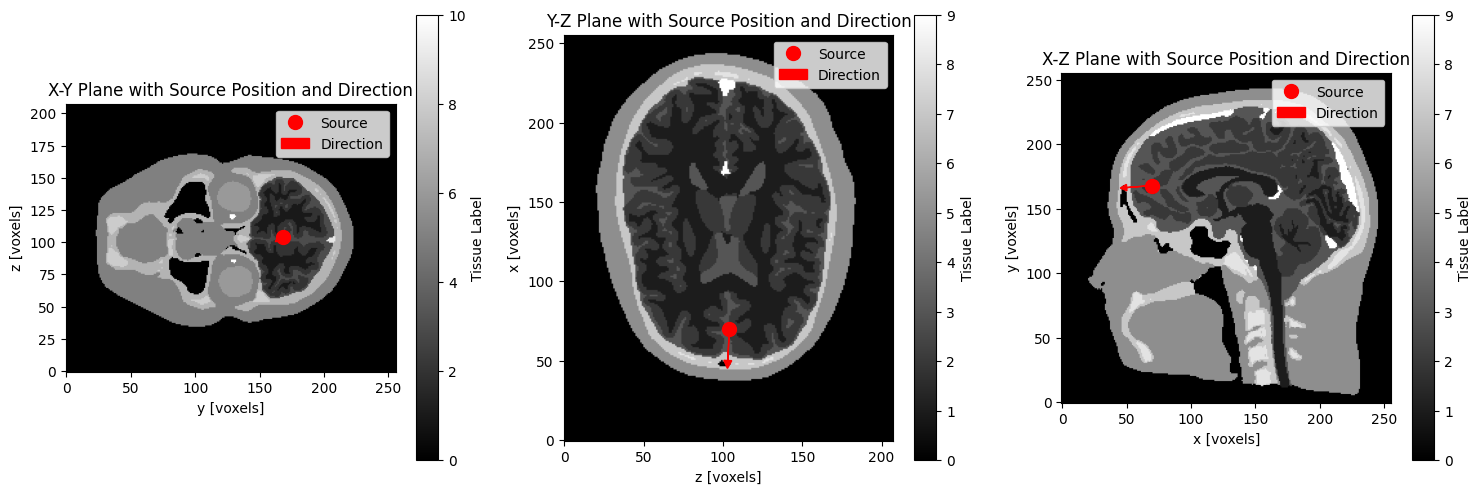

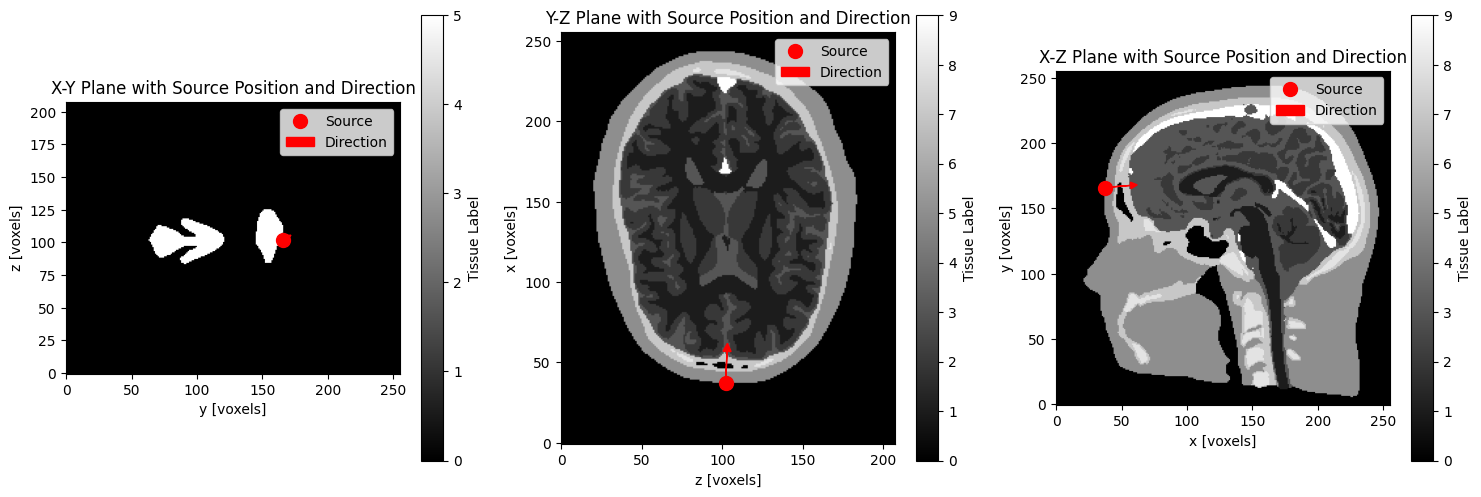

[ 37.33858648 166.01264985 102.49047595] [0.9956428  0.07995771 0.04798111] (256, 256, 208)


In [9]:
# Define the path to the NIfTI file
path = "C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\final_tissues.nii.gz"
subject_csv=r"C:\Users\liushiyu0523\Downloads\simnibs4_examples\m2m_ernie\eeg_positions\EEG10-10_UI_Jurak_2007.csv"
seg_path=r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz"
region_name="Fpz"
src_dir_mode="default" # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
inputs_dicts={
    "path":path, # subject 10 seg maps
    "subject_csv":subject_csv, # subject EEG csv
    "seg_path":seg_path, # subejct ROI seg(here = hippo)
    "region_name":region_name, # subject region
    "src_dir_mode":src_dir_mode, # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}

output_dicts=run_fn(inputs_dicts)

{'path': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\final_tissues.nii.gz', 'subject_csv': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\eeg_positions\\EEG10-10_UI_Jurak_2007.csv', 'seg_path': 'C:\\Users\\liushiyu0523\\m2m_IXI002-Guys-0828\\IXI002_out_all_fast_firstseg.nii.gz', 'region_name': 'Fpz', 'src_dir_mode': 'target'} [ 1.17227862 87.0423319  47.3397042 ]
(4, 4)
numpy space [ 52.17839704 164.90985985  74.84366634] (256, 256, 150)
real spcae [ 48.91724723 154.60299361  89.8121712 ] (240, 240, 180) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
tar_pos real space [139.91715503 113.85189132  65.12013852]
tar_pos numpy space [149.24496537 121.4420174   54.26692011]


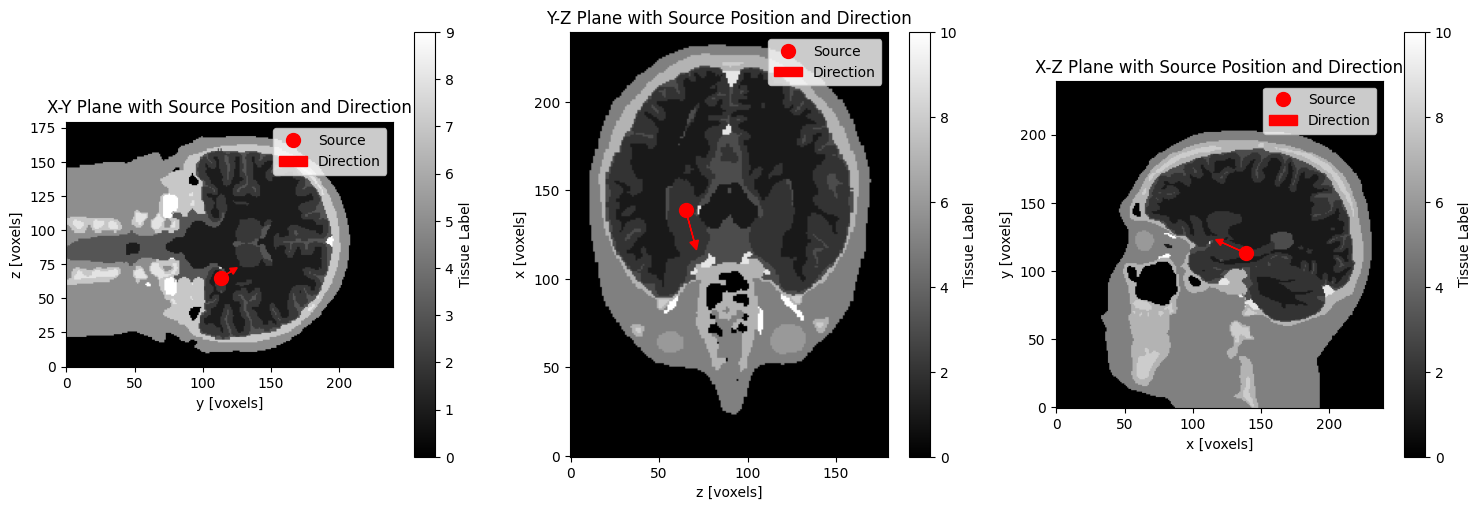

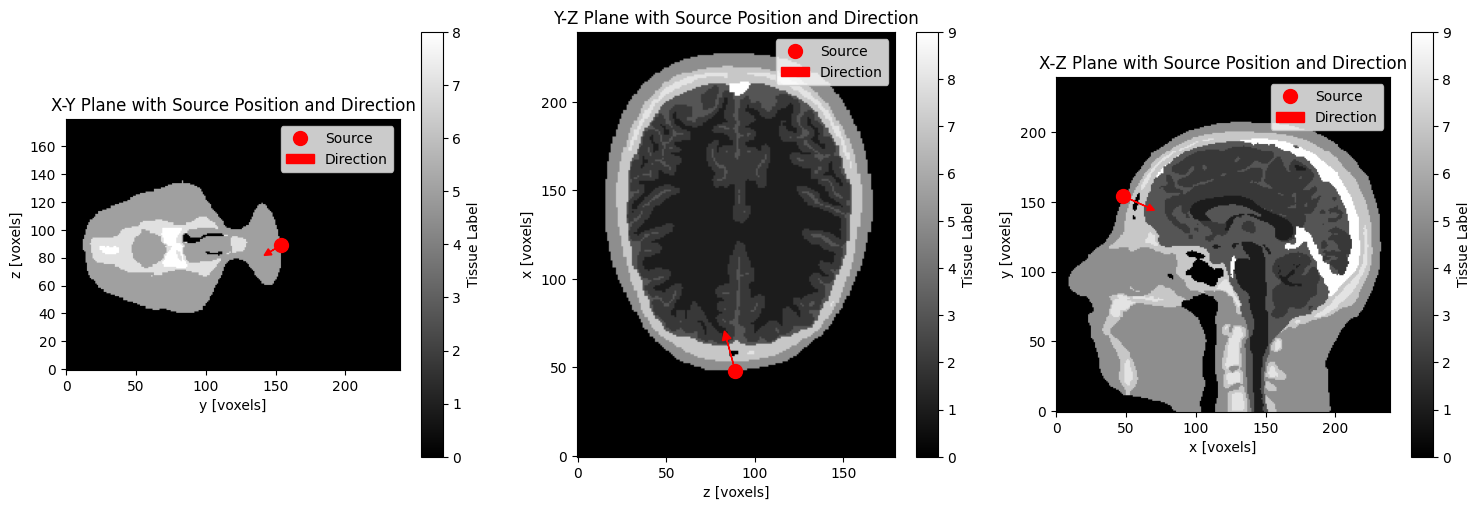

[ 48.91724723 154.60299361  89.8121712 ] [ 0.88590532 -0.39672148 -0.24038269] (240, 240, 180)


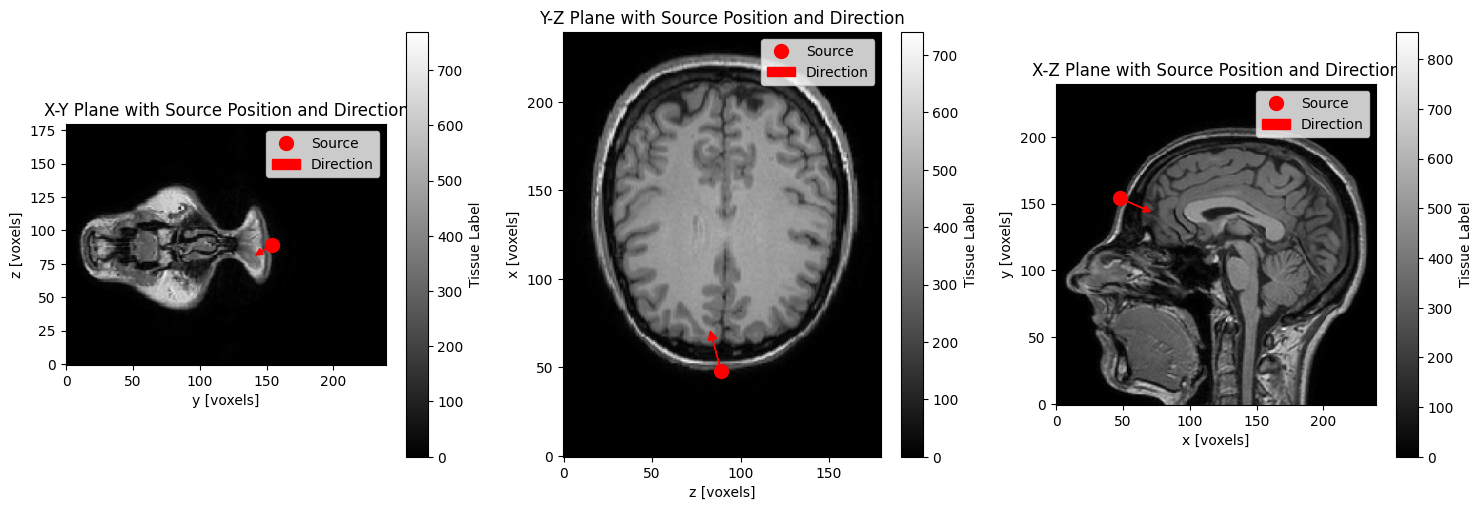

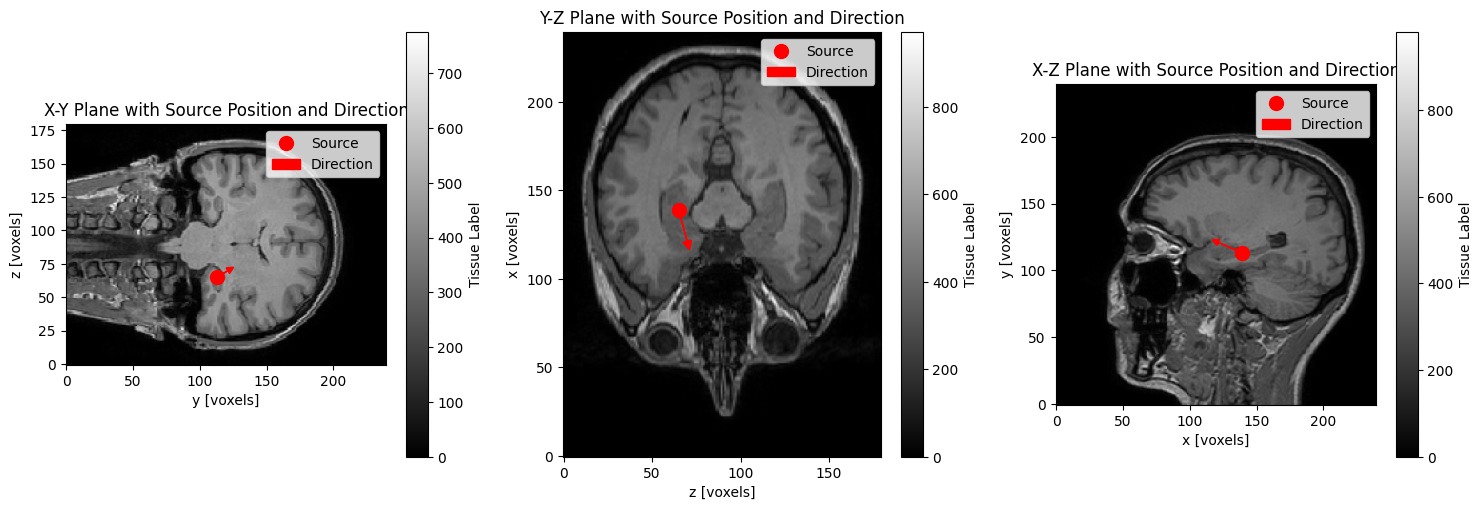

In [10]:
input_dict={
    "path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\final_tissues.nii.gz", # subject 10 seg maps
    "subject_csv":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\eeg_positions\EEG10-10_UI_Jurak_2007.csv", # subject EEG csv
    "seg_path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz", # subejct ROI seg(here = hippo)
    "region_name":region_name, # subject region
    "src_dir_mode":"target", # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}
output_dict=run_fn(input_dict)

t1_image=nib.load(r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\T1.nii.gz")
t1_vol=t1_image.get_fdata()
pixdim = t1_image.header.get_zooms()
zoom_factor=np.array(pixdim[:3]) / np.array([1.0, 1.0, 1.0])
t1_vol = zoom(t1_vol, zoom_factor, order=0)

show_src_vol(output_dict["src_pos"],output_dict["src_dir"],t1_vol)
show_src_vol(output_dict["target_position"],-output_dict["src_dir"],t1_vol)

# run experiment

(4, 4)
numpy space [ 53.9082878  162.31852576  51.514784  ] (256, 256, 150)
real spcae [ 50.53901981 152.1736179   61.81758359] (240, 240, 180) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
tar_pos real space [139.91715503 113.85189132  65.12013852]
tar_pos numpy space [149.24496537 121.4420174   54.26692011]


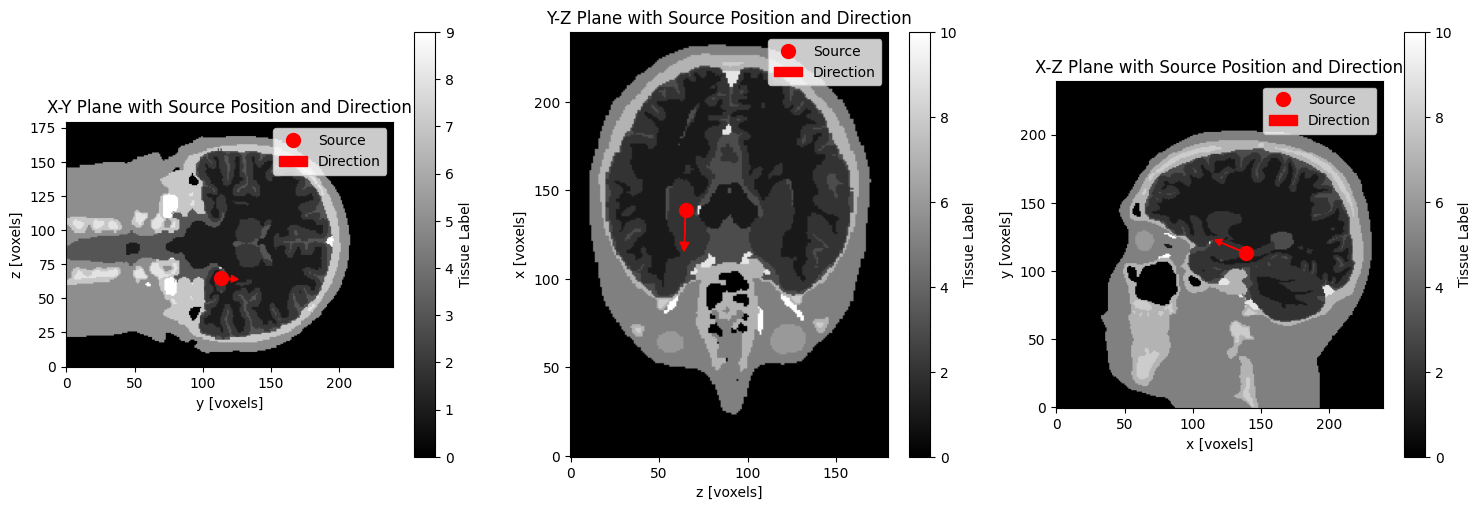

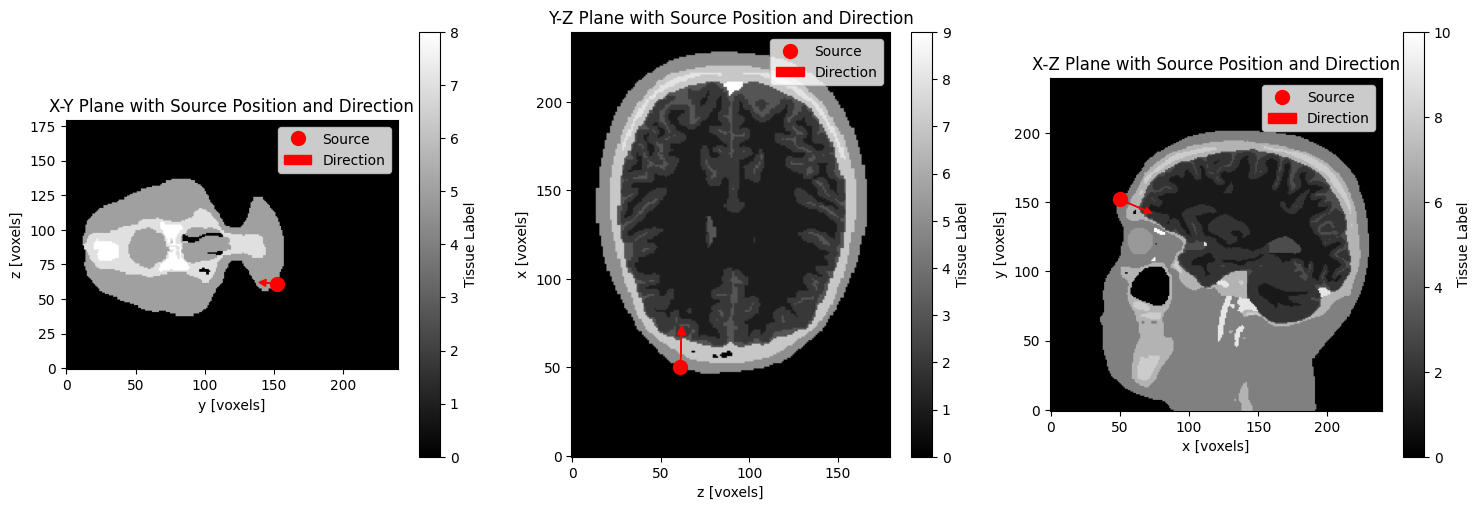

[ 50.53901981 152.1736179   61.81758359] [ 0.91855289 -0.3938383   0.03394087] (240, 240, 180)
{'nphoton': 1000000.0, 'outputtype': 'energy', 'vol': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ...

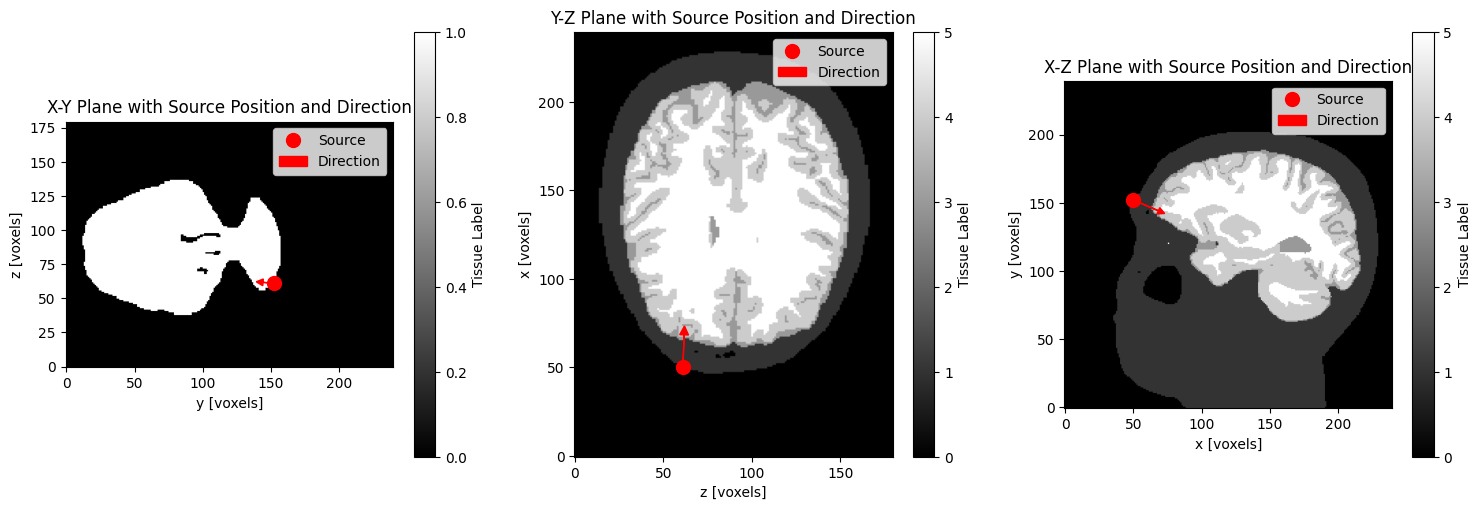

[ 50.53901981 152.1736179   61.81758359] [ 0.91855289 -0.3938383   0.03394087] (240, 240, 180)
nphoton: 1e+06
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:65: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:66: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:70: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:71: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:75: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol

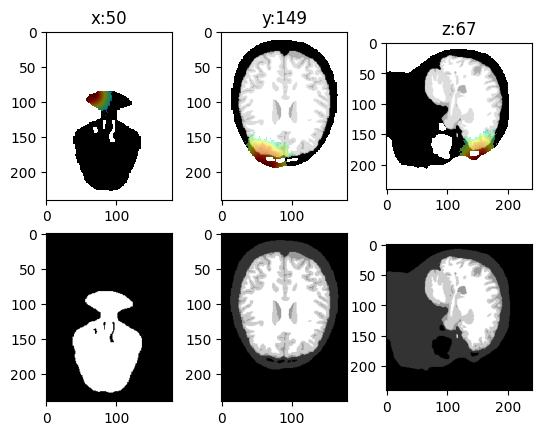

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:94: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:95: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:99: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:100: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20768\2430355287.py:104: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_v

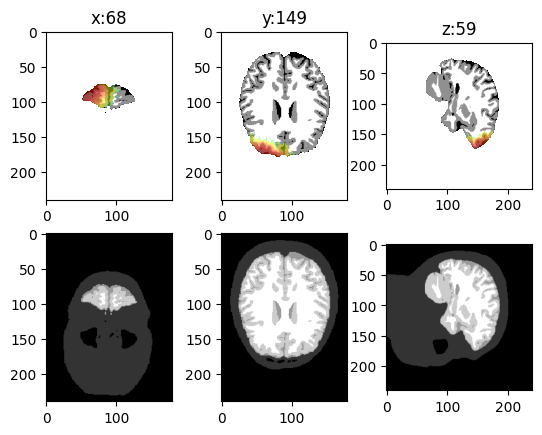

MCX results saved to C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\MCX_results.nii.gz


In [14]:
#src_pos=electrode_position
#src_dir=closest_point_index-electrode_position
#src_dir=src_dir / np.linalg.norm(src_dir)
#del path,src_pos,src_dir
input_dict={
    "path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\final_tissues.nii.gz", # subject 10 seg maps
    "subject_csv":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\eeg_positions\EEG10-10_UI_Jurak_2007.csv", # subject EEG csv
    "seg_path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz", # subejct ROI seg(here = hippo)
    "region_name":"Fp1", # subject region
    "src_dir_mode":"target", # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}
output_dict=run_fn(input_dict)
vol = output_dict["vol"]
src_dir=output_dict["src_dir"]
src_pos=output_dict["src_pos"]
output_dict["stage_2_mode"]="simple" # 1e-6 instead of many photos
#output_dict["custom_src"]=None # pass custom src setting or do nothing 
output_dict["custom_src"]={
    "srctype":"disk",
    "srcparam1":[12,0,0,0],
    "srcparam2":[0,0,0,0],
}
output_dict_2=run_fn_stage2(output_dict)
#{"res":res,"flux":flux,"resized_flux":resized_flux,"output_path":output_path}

(4, 4)
numpy space [ 53.9082878  162.31852576  51.514784  ] (256, 256, 150)
real spcae [ 50.53901981 152.1736179   61.81758359] (240, 240, 180) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
tar_pos real space [139.91715503 113.85189132  65.12013852]
tar_pos numpy space [149.24496537 121.4420174   54.26692011]


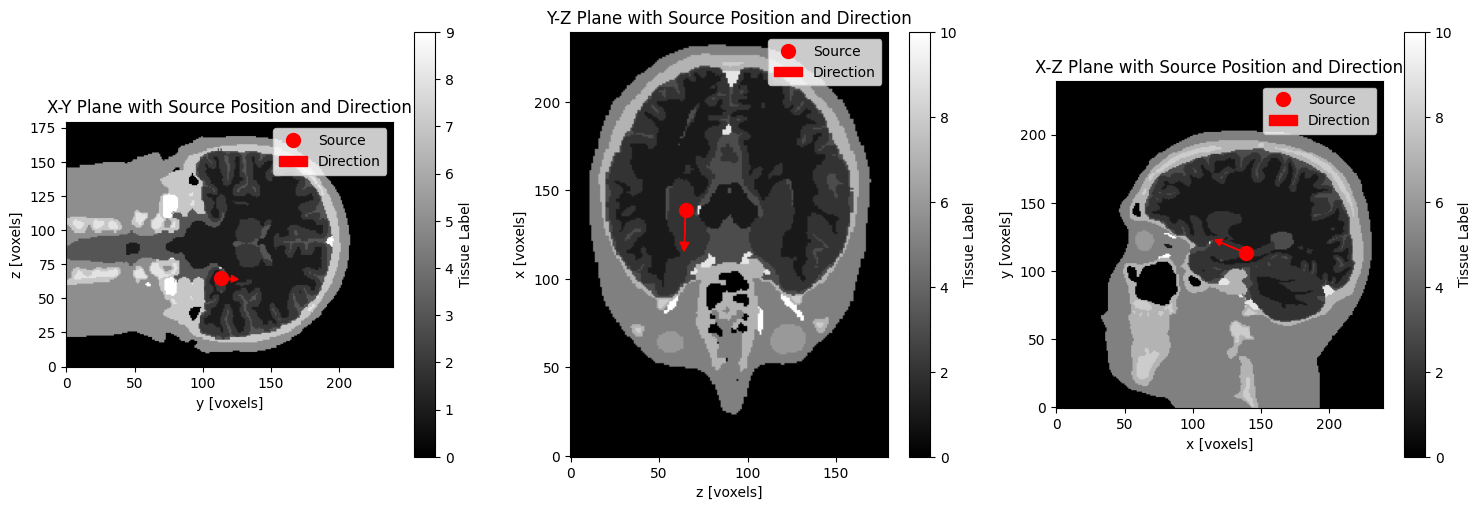

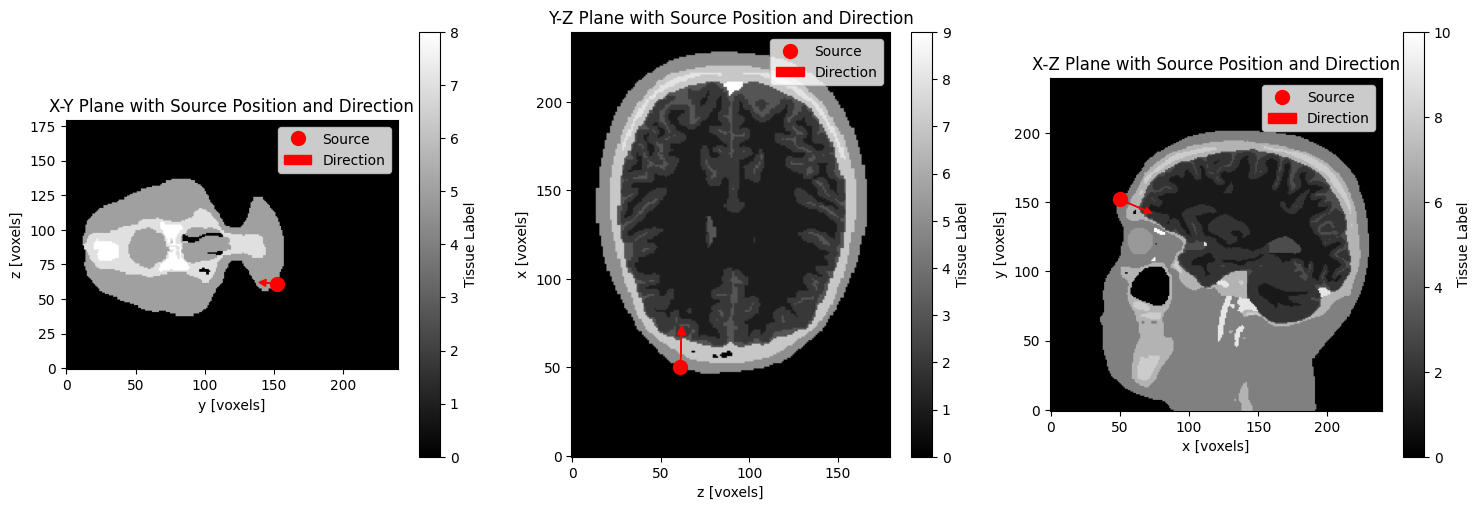

[ 50.53901981 152.1736179   61.81758359] [ 0.91855289 -0.3938383   0.03394087] (240, 240, 180)
{'nphoton': 22302477099.15625, 'outputtype': 'energy', 'vol': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0

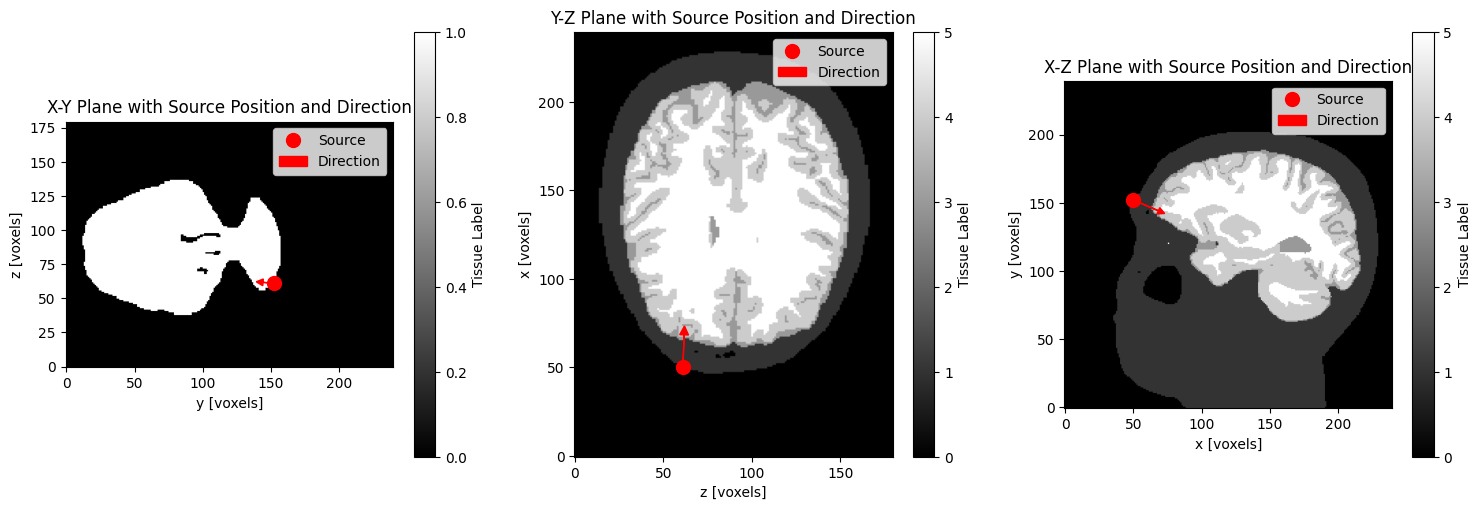

[ 50.53901981 152.1736179   61.81758359] [ 0.91855289 -0.3938383   0.03394087] (240, 240, 180)
nphoton: 2.23025e+10
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


In [ ]:
#src_pos=electrode_position
#src_dir=closest_point_index-electrode_position
#src_dir=src_dir / np.linalg.norm(src_dir)
#del path,src_pos,src_dir
input_dict={
    "path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\final_tissues.nii.gz", # subject 10 seg maps
    "subject_csv":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\eeg_positions\EEG10-10_UI_Jurak_2007.csv", # subject EEG csv
    "seg_path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz", # subejct ROI seg(here = hippo)
    "region_name":"Fp1", # subject region
    "src_dir_mode":"target", # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}
output_dict=run_fn(input_dict)
vol = output_dict["vol"]
src_dir=output_dict["src_dir"]
src_pos=output_dict["src_pos"]
output_dict["stage_2_mode"]="full" # 1e-6 instead of many photos
#output_dict["custom_src"]=None # pass custom src setting or do nothing 
output_dict["custom_src"]={
    "srctype":"disk",
    "srcparam1":[12,0,0,0],
    "srcparam2":[0,0,0,0],
}
output_dict_2=run_fn_stage2(output_dict)
#{"res":res,"flux":flux,"resized_flux":resized_flux,"output_path":output_path}

Mean center of top 5% values: [101.37431447 159.54199242 122.68785006]
Distance from target to mean center: 82.98901920873983
real_space mean_center: [101.37431447 159.54199242 122.68785006] ,tar_pos [139.91715503 113.85189132  65.12013852]


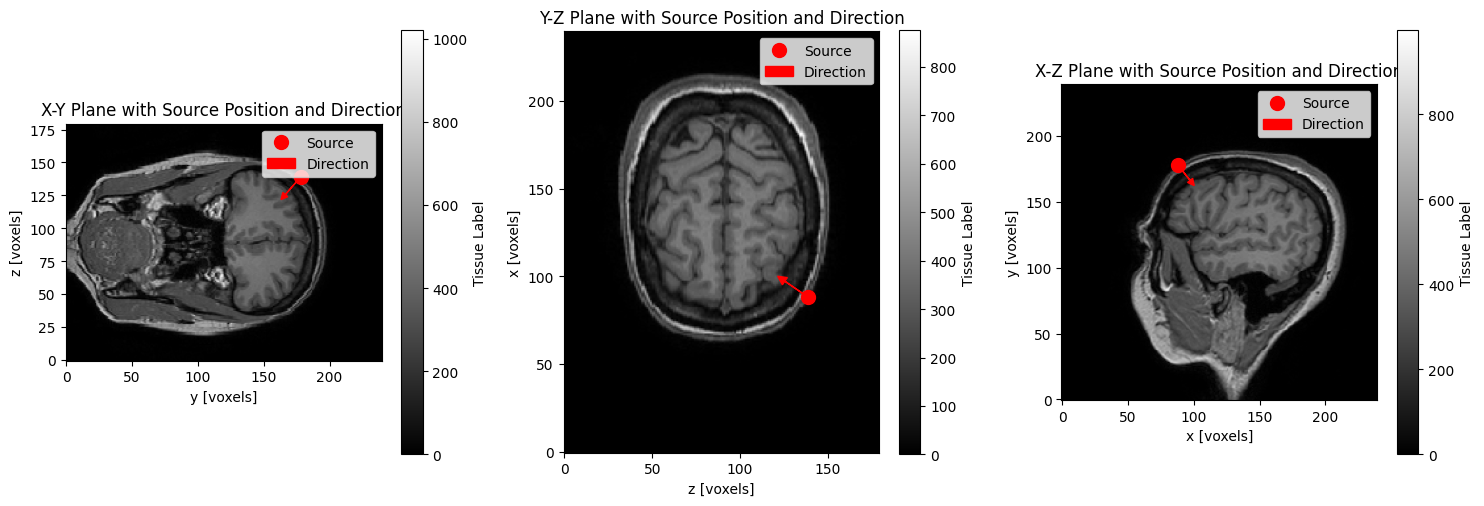

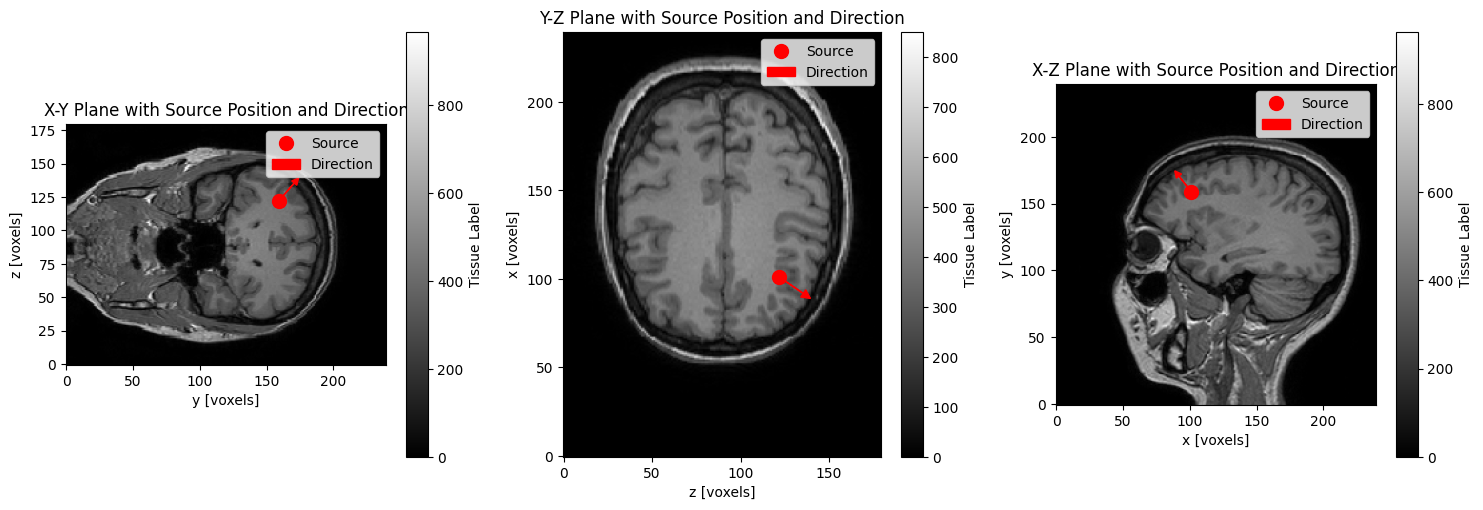

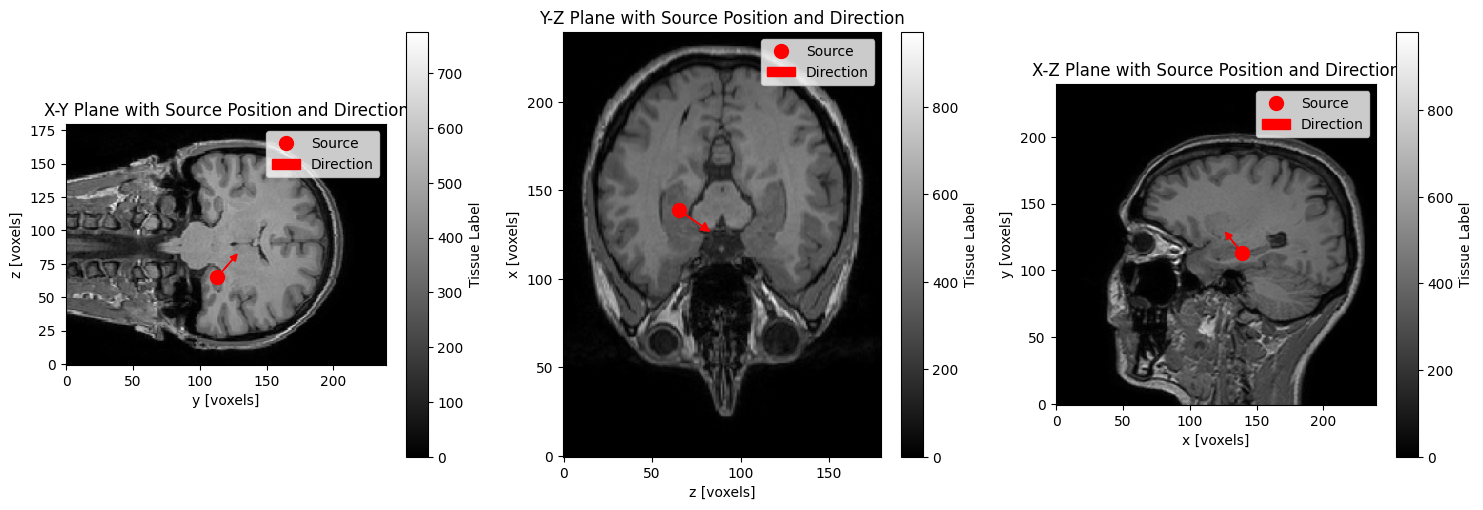

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:65: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:66: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:70: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:71: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:75: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol

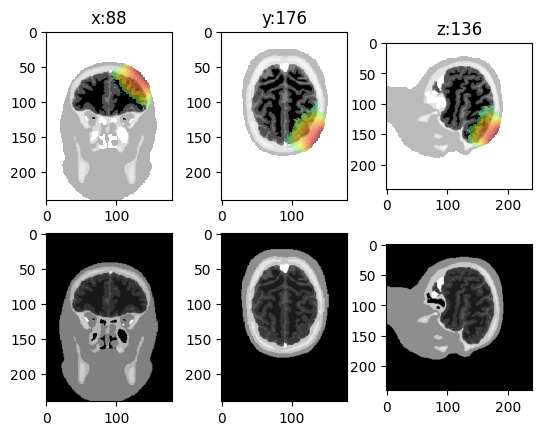

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:94: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:95: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:99: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:100: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_14372\2712029468.py:104: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_v

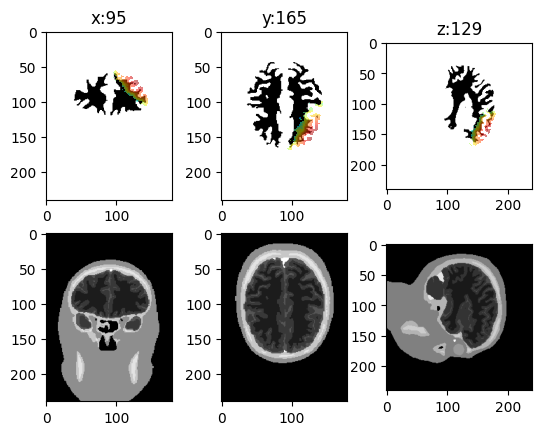

array([ 88.84991741, 178.27262789, 139.33324299])

In [36]:
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

def calculate_distance_to_top_values(flux, target_position, mask,top_percent=5):
    flux=flux.sum(axis=-1)
    flux = flux.astype(np.float32)
    flux *=mask
    non_zero_flux = flux[flux > np.percentile(flux,0.5)]
    num_top_values = int(np.ceil(len(non_zero_flux) * top_percent / 100.0))
    threshold_value = np.partition(non_zero_flux, -num_top_values)[-num_top_values]
    top_mask = (flux >= threshold_value)
    
    # Extract the coordinates of the top `top_percent` values
    top_coords = np.argwhere(top_mask)
    
    # Compute the mean position of the top `top_percent` values
    mean_center = np.mean(top_coords, axis=0)
    
    # Calculate the Euclidean distance from the target position to the mean center
    distance = np.linalg.norm(np.array(target_position) - mean_center)
    
    return mean_center, distance

target_position = output_dict["src_pos"]
mean_center, distance = calculate_distance_to_top_values(
    output_dict_2["flux"], 
    output_dict["target_position"],
    #np.logical_or(output_dict["vol"]>0,output_dict["vol"]<4),
    output_dict["vol"]<3,
    top_percent=95
) 

print(f"Mean center of top 5% values: {mean_center}")
print(f"Distance from target to mean center: {distance}")

print("real_space","mean_center:",mean_center,",tar_pos",output_dict["target_position"])
show_src_vol(output_dict["src_pos"],output_dict["src_dir"],t1_vol)
show_src_vol(mean_center,-output_dict["src_dir"],t1_vol)
show_src_vol(output_dict["target_position"],-output_dict["src_dir"],t1_vol)
view_result(output_dict_2["res"],output_dict["vol"])
view_result_mask(output_dict_2["res"],10*output_dict["vol"],output_dict["vol"]<3)
np.linalg.norm(np.array(target_position) - mean_center)
target_position




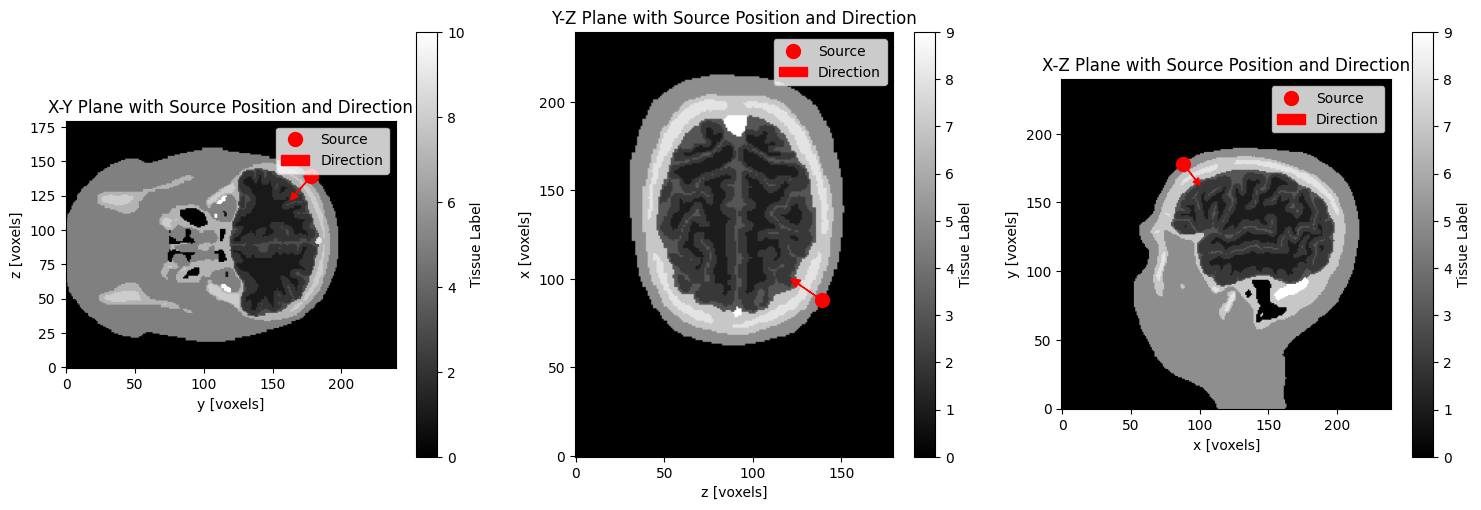

In [37]:
show_src_vol(output_dict["src_pos"],output_dict["src_dir"],output_dict["vol"])
show_src_vol(output_dict["src_pos"],output_dict["src_dir"],output_dict["vol"])

D:\SimNibs\simnibs_env\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
D:\SimNibs\simnibs_env\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


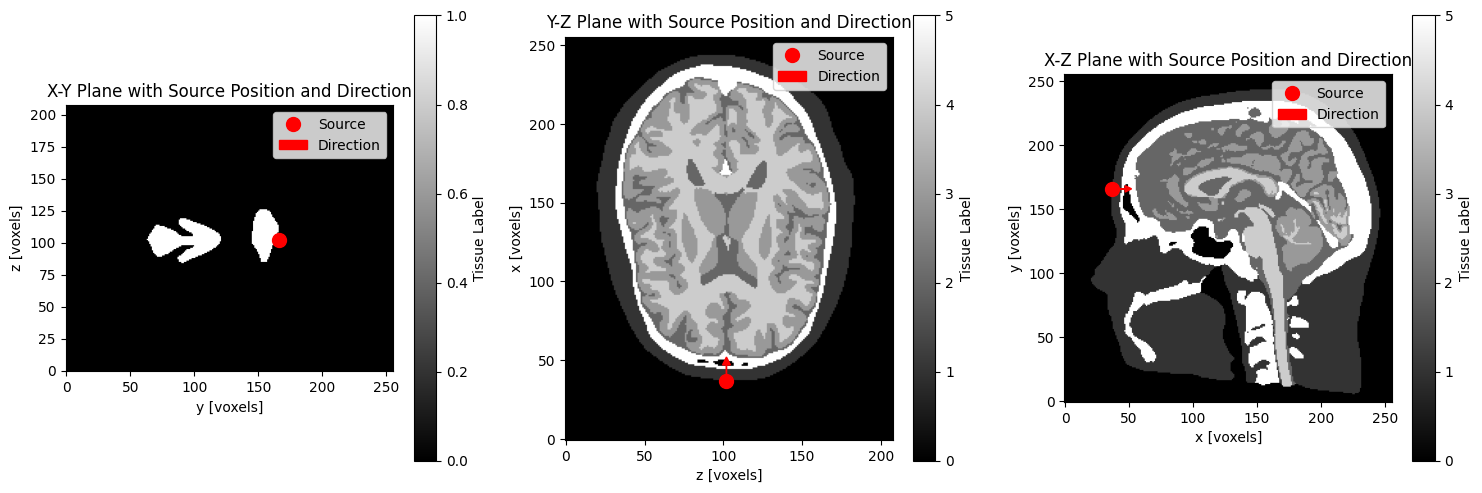

[ 37.33858648 166.01264985 102.49047595] [1. 0. 0.] (256, 256, 208)
nphoton: 1e+06
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:63: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:64: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:68: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:69: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:73: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :

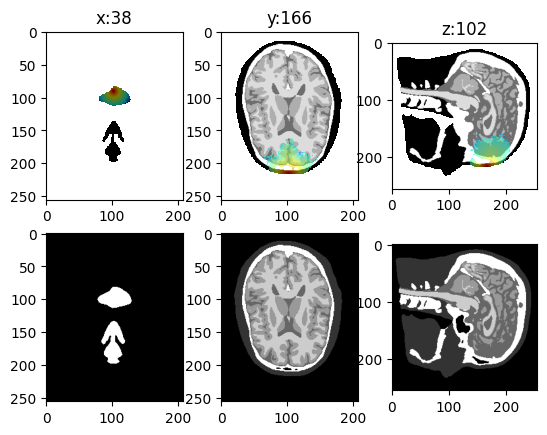

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:92: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:93: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:98: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:102: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, 

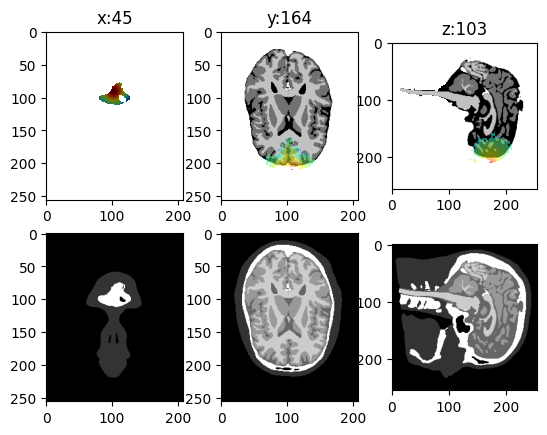

In [77]:
#src_pos=electrode_position
#src_dir=closest_point_index-electrode_position
#src_dir=src_dir / np.linalg.norm(src_dir)
#del path,src_pos,src_dir
input_dict={
    "path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\final_tissues.nii.gz", # subject 10 seg maps
    "subject_csv":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\eeg_positions\EEG10-10_UI_Jurak_2007.csv", # subject EEG csv
    "seg_path":r"C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\IXI002_out_all_fast_firstseg.nii.gz", # subejct ROI seg(here = hippo)
    "region_name":region_name, # subject region
    "src_dir_mode":"target", # subject mode: # fixed: const, default: to cortex min distance, target: use a seg_path for hippocampus
}
output_dict=run_fn(input_dict)
vol = output_dict["vol"]
src_dir=output_dict["src_dir"]
src_pos=output_dict["src_pos"]
 

!python -c "import pmcx" || pip install -q  pmcx 
!python -c "import nibabel" || pip install -q  nibabel 
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import scipy.io as sio
import pmcx

if False:
  # Load data
  isub = 4
  file_name = f'sub-{isub}'

  scalp = sio.loadmat('tess_head_mask.mat')['mrimask'].astype(np.uint8)
  ambient_air = np.zeros_like(scalp)

  csf = sio.loadmat(f'subjectimage_{file_name}_label-CSF_probseg_resample.mat')['Cube']
  gm = sio.loadmat(f'subjectimage_{file_name}_label-GM_probseg_resample.mat')['Cube']
  wm = sio.loadmat(f'subjectimage_{file_name}_label-WM_probseg_resample.mat')['Cube']

  individual_atlas = ambient_air.copy()
  individual_atlas[scalp != 0] = 1
  individual_atlas[csf != 0] = 2
  individual_atlas[gm != 0] = 3
  individual_atlas[wm != 0] = 4
if True:
  ambient_air = np.zeros_like(vol)
  individual_atlas=np.zeros_like(vol)
  # map scalp,csf,gm,wm,air to 1,2,3,4 and rest to 0
  # prop=[
  #   [0, 0, 1, 1], # air
  #   [0.092,38,0.89,1.37], # WM
  #   [0.028,7.3,0.89,1.37], # GM
  #   [0.0026,0.091,0.89,1.37],# CSF
  #   [0,0,1,1], # #4 things
  #   [0.0168,17.82,0.89,1.37],# Scalp
  #   [0,0,1,1],# Eye_balss assuming as air
  #   [0.011,17.82,0.89,1.37],# Compact_bone
  #   [0.011,17.82,0.89,1.37],# Spongy_bone
  #   [0,0,1,1],# Blood assuming as air
  #   [0,0,1,1],# Muscle assuming as air
  # ]
  individual_atlas[vol >0] = 1 # as scalp
  individual_atlas[vol == 5] = 1 # scalp
  individual_atlas[vol == 7] = 2 # skull
  individual_atlas[vol == 8] = 2 # skull
  individual_atlas[vol == 3] = 3 # csf
  individual_atlas[vol == 2] = 4 # gm
  individual_atlas[vol == 1] = 5 # wm 
  individual_atlas[vol >5] = 1 # air 

# Light parameters
length = 1064
d = 1
p = 250
t = 8
timwin = 1e-9

light_parameter = np.array([
    [0, 0, 1, 1],# air
    [0.017, 18.45, 0.89, 1.37],# scalp
    [0.019, 14.6, 0.89, 1.37],# skull 
    [0.0144, 0.09, 0.89, 1.37],# csf
    [0.053, 5.9, 0.91, 1.37],#gm
    [0.105, 30, 0.88, 1.37],# wm
    #[0.033,9.35,0.89,1.37], # ECT
    [0.105,30,0.88,1.37] # air cavities
])
#[N]= power2photon(d,p,t,length);

# light_parameter = np.array([
#     [0, 0, 1, 1],# air
#     [0.017, 18.45, 0.89, 1.37],
#     [0.0168,17.82,0.89,1.37],#[0.019, 14.6, 0.89, 1.37],# scalp
#     [0.0026,0.091,0.89,1.37],#[0.0144, 0.09, 0.89, 1.37],# csf
#     [0.028,7.3,0.89,1.37],#[0.053, 5.9, 0.91, 1.37],#gm
#     [0.092,38,0.89,1.37],#[0.105, 30, 0.88, 1.37]# wm
# ])

# Function to convert power to photon
def power2photon(d, p, t, length):
    h = 6.62607015e-34  # Planck constant
    c = 3e8  # Speed of light
    E = (h * c) / (length * 1e-9)  # Energy per photon
    N = (p * d * t) / E  # Number of photons
    return N
N = power2photon(d, p, t, length)
# MCX configuration


cfg = {
    'nphoton': etimwin * N / (t * 60),
    'outputtype': 'energy',
    'vol': individual_atlas,
    'prop': light_parameter[[0, 1, 2, 3, 4,5], :].tolist(),
    'srcnum': 1,
    'srcpos': src_pos,#f3_subject_pos,#[100, 175, 215.0700],
    'srctype': 'pencil',
    'srcdir': src_dir,#[-0.5086, -0.1822, -0.8415],
    'issrcfrom0': 1,
    'tstart': 0,
    'tend': timwin,
    'tstep': timwin,
    'isspecular': 0,
    'isreflect': 1,
    'autopilot': 1,
    'gpuid': 1
}

# check source 
show_src_vol(cfg["srcpos"],cfg["srcdir"],cfg["vol"])
print(cfg["srcpos"],cfg["srcdir"],cfg["vol"].shape)


# Run MCX simulation
res = pmcx.mcxlab(cfg)
flux = res['flux']


view_result(res,cfg["vol"])
view_result_mask(res,cfg["vol"],cfg["vol"]>2)


original_img=nib.load(input_dict["path"])
original_affine = original_img.affine
original_pixdim = original_img.header.get_zooms()
flux_pixdim = np.ones_like(original_pixdim)  # Voxel dimensions for flux data
zoom_factors = flux_pixdim / original_pixdim
resized_flux = zoom(flux, zoom_factors, order=1)  # Use order=1 for linear interpolation
resized_flux = resized_flux.astype(np.float32)
nii_image = nib.Nifti1Image(resized_flux, original_affine)
output_path = r'C:\Users\liushiyu0523\m2m_IXI002-Guys-0828\MCX_results.nii.gz'
# Save the NIfTI image to a file
nib.save(nii_image, output_path)
print(f"MCX results saved to {output_path}")

D:\SimNibs\simnibs_env\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
D:\SimNibs\simnibs_env\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\SimNibs\simnibs_env\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


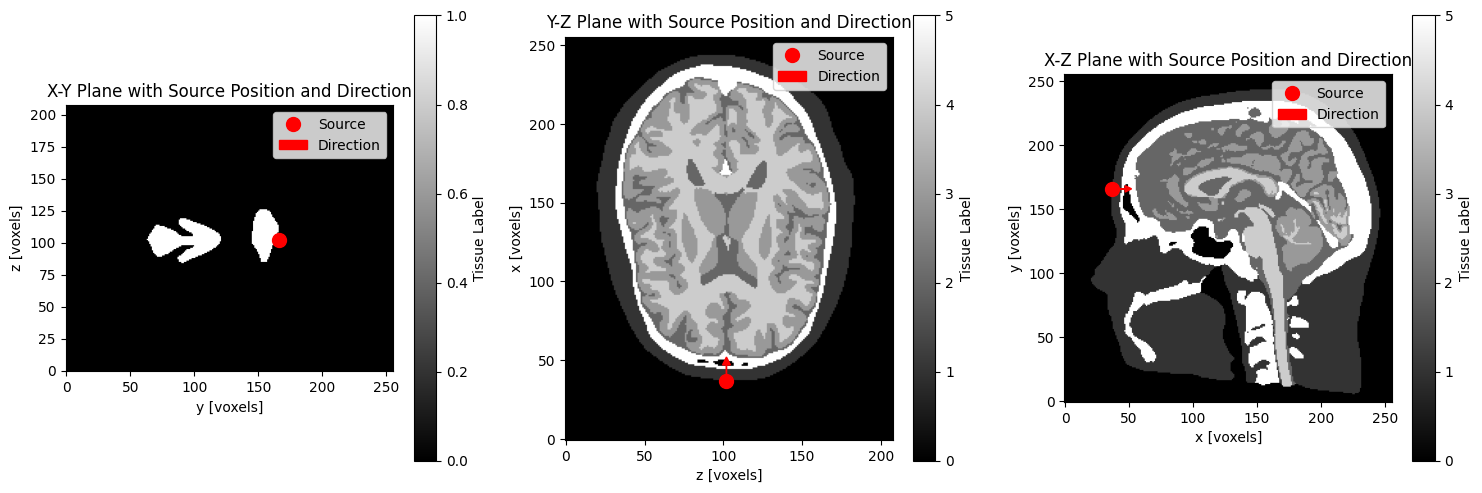

[ 37.33858648 166.01264985 102.49047595] [1. 0. 0.] (256, 256, 208)
nphoton: 2.23025e+10
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:63: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:64: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:68: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:69: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:73: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :

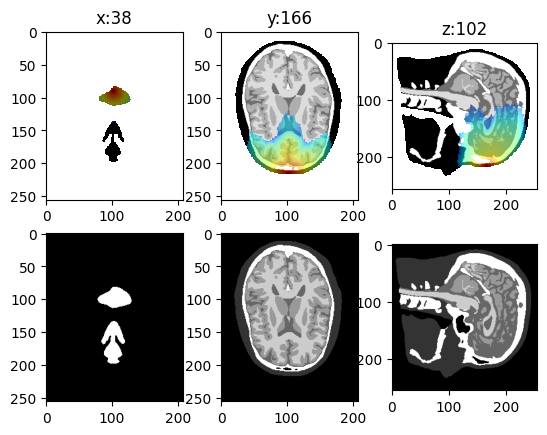

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:92: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:93: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:98: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:102: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, 

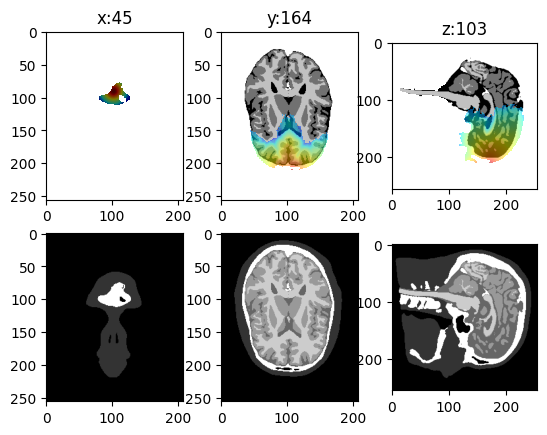

In [78]:
# src_pos=electrode_position
# src_dir=closest_point_index-electrode_position
# src_dir=src_dir / np.linalg.norm(src_dir)

!python -c "import pmcx" || pip install -q  pmcx 
!python -c "import nibabel" || pip install -q  nibabel 
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import scipy.io as sio
import pmcx

if False:
  # Load data
  isub = 4
  file_name = f'sub-{isub}'

  scalp = sio.loadmat('tess_head_mask.mat')['mrimask'].astype(np.uint8)
  ambient_air = np.zeros_like(scalp)

  csf = sio.loadmat(f'subjectimage_{file_name}_label-CSF_probseg_resample.mat')['Cube']
  gm = sio.loadmat(f'subjectimage_{file_name}_label-GM_probseg_resample.mat')['Cube']
  wm = sio.loadmat(f'subjectimage_{file_name}_label-WM_probseg_resample.mat')['Cube']

  individual_atlas = ambient_air.copy()
  individual_atlas[scalp != 0] = 1
  individual_atlas[csf != 0] = 2
  individual_atlas[gm != 0] = 3
  individual_atlas[wm != 0] = 4
if True:
  data=nib.load(path).get_fdata()[...,0].astype('uint8')
  ambient_air = np.zeros_like(data)
  individual_atlas=np.zeros_like(data)
  # map scalp,csf,gm,wm,air to 1,2,3,4 and rest to 0
  # prop=[
  #   [0, 0, 1, 1], # air
  #   [0.092,38,0.89,1.37], # WM
  #   [0.028,7.3,0.89,1.37], # GM
  #   [0.0026,0.091,0.89,1.37],# CSF
  #   [0,0,1,1], # #4 things
  #   [0.0168,17.82,0.89,1.37],# Scalp
  #   [0,0,1,1],# Eye_balss assuming as air
  #   [0.011,17.82,0.89,1.37],# Compact_bone
  #   [0.011,17.82,0.89,1.37],# Spongy_bone
  #   [0,0,1,1],# Blood assuming as air
  #   [0,0,1,1],# Muscle assuming as air
  # ]
  individual_atlas[data >0] = 2
  individual_atlas[data == 5] = 1 # scalp
  individual_atlas[data == 3] = 2 # csf
  individual_atlas[data == 2] = 3 # gm
  individual_atlas[data == 1] = 4 # wm
  individual_atlas[data >5] = 5 # ECT

# Light parameters
length = 1064
d = 1
p = 250
t = 8
timwin = 1e-9

light_parameter = np.array([
    [0, 0, 1, 1],# air
    [0.017, 18.45, 0.89, 1.37],
    [0.019, 14.6, 0.89, 1.37],# scalp
    [0.0144, 0.09, 0.89, 1.37],# csf
    [0.053, 5.9, 0.91, 1.37],#gm
    [0.105, 30, 0.88, 1.37],# wm
    [0.033,9.35,0.89,1.37], # ECT
])

# light_parameter = np.array([
#     [0, 0, 1, 1],# air
#     [0.017, 18.45, 0.89, 1.37],
#     [0.0168,17.82,0.89,1.37],#[0.019, 14.6, 0.89, 1.37],# scalp
#     [0.0026,0.091,0.89,1.37],#[0.0144, 0.09, 0.89, 1.37],# csf
#     [0.028,7.3,0.89,1.37],#[0.053, 5.9, 0.91, 1.37],#gm
#     [0.092,38,0.89,1.37],#[0.105, 30, 0.88, 1.37]# wm
# ])

# Function to convert power to photon
def power2photon(d, p, t, length):
    h = 6.62607015e-34  # Planck constant
    c = 3e8  # Speed of light
    E = (h * c) / (length * 1e-9)  # Energy per photon
    N = (p * d * t) / E  # Number of photons
    return N
N = power2photon(d, p, t, length)
# MCX configuration


cfg = {
    'nphoton': timwin * N / (t * 60),
    'outputtype': 'energy',
    'vol': individual_atlas,
    'prop': light_parameter[[0, 2, 3, 4, 5,6], :].tolist(),
    'srcnum': 1,
    'srcpos': src_pos,#f3_subject_pos,#[100, 175, 215.0700],
    'srctype': 'pencil',
    'srcdir': src_dir,#[-0.5086, -0.1822, -0.8415],
    'issrcfrom0': 1,
    'tstart': 0,
    'tend': timwin,
    'tstep': timwin,
    'isspecular': 0,
    'isreflect': 1,
    'autopilot': 1,
    'gpuid': 1
}

# check source 
show_src_vol(cfg["srcpos"],cfg["srcdir"],cfg["vol"])
print(cfg["srcpos"],cfg["srcdir"],cfg["vol"].shape)


# Run MCX simulation
res = pmcx.mcxlab(cfg)
flux = res['flux']


view_result(res,cfg["vol"])
view_result_mask(res,cfg["vol"],cfg["vol"]>1)

In [97]:
def quick_sim(src_pos,src_dir):
    import numpy as np
    import nibabel as nib
    import matplotlib.pyplot as plt
    import scipy.io as sio
    import pmcx
    
    if False:
      # Load data
      isub = 4
      file_name = f'sub-{isub}'
    
      scalp = sio.loadmat('tess_head_mask.mat')['mrimask'].astype(np.uint8)
      ambient_air = np.zeros_like(scalp)
    
      csf = sio.loadmat(f'subjectimage_{file_name}_label-CSF_probseg_resample.mat')['Cube']
      gm = sio.loadmat(f'subjectimage_{file_name}_label-GM_probseg_resample.mat')['Cube']
      wm = sio.loadmat(f'subjectimage_{file_name}_label-WM_probseg_resample.mat')['Cube']
    
      individual_atlas = ambient_air.copy()
      individual_atlas[scalp != 0] = 1
      individual_atlas[csf != 0] = 2
      individual_atlas[gm != 0] = 3
      individual_atlas[wm != 0] = 4
    if True:
      data=nib.load(path).get_fdata()[...,0].astype('uint8')
      ambient_air = np.zeros_like(data)
      individual_atlas=np.zeros_like(data)
      # map scalp,csf,gm,wm,air to 1,2,3,4 and rest to 0
      # prop=[
      #   [0, 0, 1, 1], # air
      #   [0.092,38,0.89,1.37], # WM
      #   [0.028,7.3,0.89,1.37], # GM
      #   [0.0026,0.091,0.89,1.37],# CSF
      #   [0,0,1,1], # #4 things
      #   [0.0168,17.82,0.89,1.37],# Scalp
      #   [0,0,1,1],# Eye_balss assuming as air
      #   [0.011,17.82,0.89,1.37],# Compact_bone
      #   [0.011,17.82,0.89,1.37],# Spongy_bone
      #   [0,0,1,1],# Blood assuming as air
      #   [0,0,1,1],# Muscle assuming as air
      # ]
      individual_atlas[data >0] = 2
      individual_atlas[data == 5] = 1 # scalp
      individual_atlas[data == 3] = 2 # csf
      individual_atlas[data == 2] = 3 # gm
      individual_atlas[data == 1] = 4 # wm
      individual_atlas[data >5] = 5 # ECT
    
    # Light parameters
    length = 1064
    d = 1
    p = 250
    t = 8
    timwin = 1e-9
    
    light_parameter = np.array([
        [0, 0, 1, 1],# air
        [0.017, 18.45, 0.89, 1.37],
        [0.019, 14.6, 0.89, 1.37],# scalp
        [0.0144, 0.09, 0.89, 1.37],# csf
        [0.053, 5.9, 0.91, 1.37],#gm
        [0.105, 30, 0.88, 1.37],# wm
        [0.033,9.35,0.89,1.37], # ECT
    ])
    
    # light_parameter = np.array([
    #     [0, 0, 1, 1],# air
    #     [0.017, 18.45, 0.89, 1.37],
    #     [0.0168,17.82,0.89,1.37],#[0.019, 14.6, 0.89, 1.37],# scalp
    #     [0.0026,0.091,0.89,1.37],#[0.0144, 0.09, 0.89, 1.37],# csf
    #     [0.028,7.3,0.89,1.37],#[0.053, 5.9, 0.91, 1.37],#gm
    #     [0.092,38,0.89,1.37],#[0.105, 30, 0.88, 1.37]# wm
    # ])
    
    # Function to convert power to photon
    def power2photon(d, p, t, length):
        h = 6.62607015e-34  # Planck constant
        c = 3e8  # Speed of light
        E = (h * c) / (length * 1e-9)  # Energy per photon
        N = (p * d * t) / E  # Number of photons
        return N
    N = power2photon(d, p, t, length)
    # MCX configuration
    
    
    cfg = {
        'nphoton': 1e6,#etimwin * N / (t * 60),
        'outputtype': 'energy',
        'vol': individual_atlas,
        'prop': light_parameter[[0, 2, 3, 4, 5,6], :].tolist(),
        'srcnum': 1,
        'srcpos': src_pos,#f3_subject_pos,#[100, 175, 215.0700],
        'srctype': 'pencil',
        'srcdir': src_dir,#[-0.5086, -0.1822, -0.8415],
        'issrcfrom0': 1,
        'tstart': 0,
        'tend': timwin,
        'tstep': timwin,
        'isspecular': 0,
        'isreflect': 1,
        'autopilot': 1,
        'gpuid': 1
    }
    
    # check source 
    show_src_vol(cfg["srcpos"],cfg["srcdir"],cfg["vol"])
    print(cfg["srcpos"],cfg["srcdir"],cfg["vol"].shape)
    
    
    # Run MCX simulation
    res = pmcx.mcxlab(cfg)
    flux = res['flux']
    
    
    view_result(res,cfg["vol"])
    view_result_mask(res,cfg["vol"],cfg["vol"]>1)

    return res

[ 37.33858648 166.01264985 102.49047595]


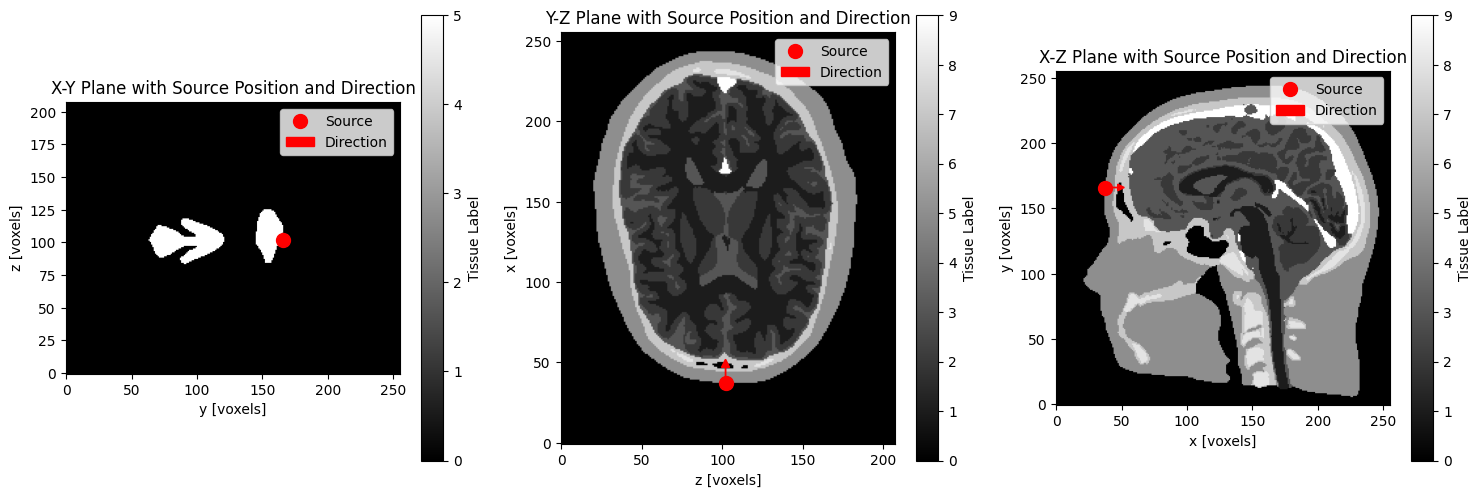

[ 37.33858648 166.01264985 102.49047595] [1. 0. 0.] (256, 256, 208)


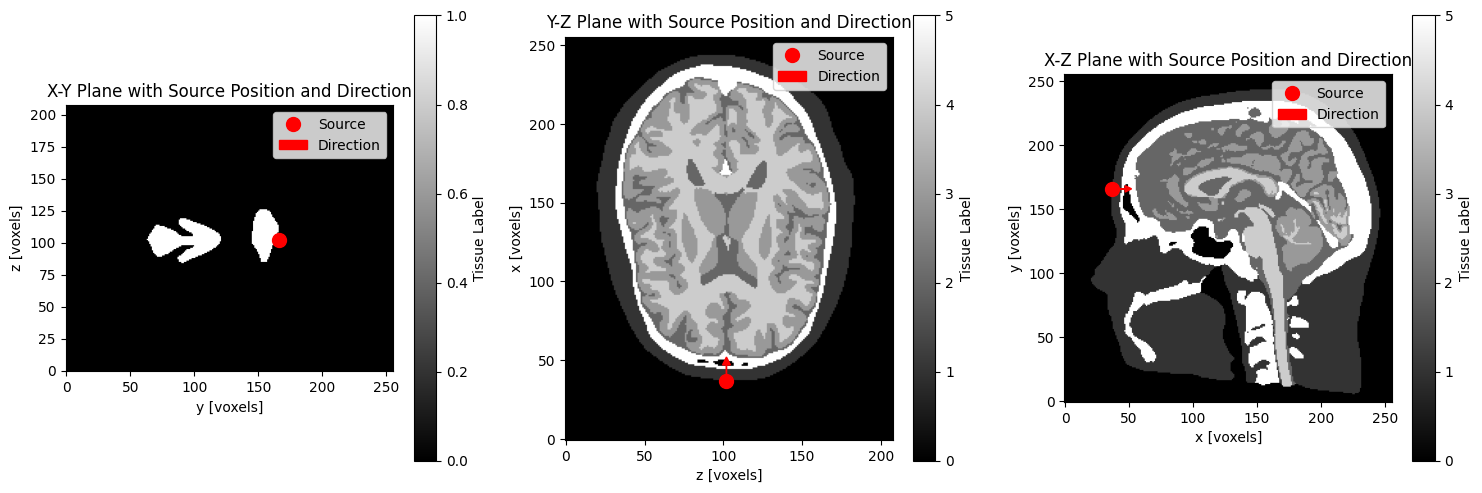

[ 37.33858648 166.01264985 102.49047595] [1. 0. 0.] (256, 256, 208)
nphoton: 1e+06
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:63: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:64: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:68: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:69: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:73: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :

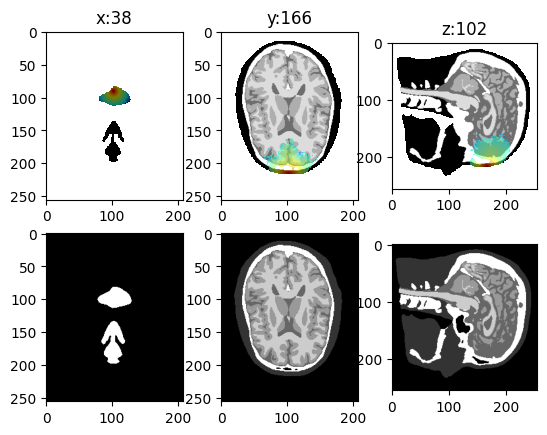

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:92: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:93: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:97: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:98: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_20188\317743505.py:102: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, 

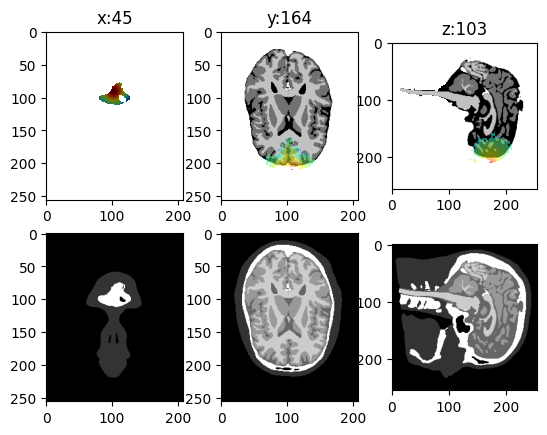

{'flux': array([[[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         ...,
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]]],
 
 
        [[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...

In [99]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Define the path to the NIfTI file
path = "C:\\Users\\liushiyu0523\\Downloads\\simnibs4_examples\\m2m_ernie\\final_tissues.nii.gz"
subject_csv=r"C:\Users\liushiyu0523\Downloads\simnibs4_examples\m2m_ernie\eeg_positions\EEG10-10_UI_Jurak_2007.csv"
region_name="Fpz"
Fpz_subject=from_csv_get_subject_coord(subject_csv,region_name)
img = nib.load(path)
vol=img.get_fdata()[...,0].astype('uint8')
affine_matrix = img.affine
image_coord = np.linalg.inv(affine_matrix) @ np.append(Fpz_subject, 1)
src_pos = image_coord[:3]
print(src_pos)

if False:
    for src_dir in [np.array([1.,0.,0.]),np.array([0.,1.,0.]),np.array([0.,0.,1.,])]:
        show_src_vol(src_pos,src_dir,vol)
        print(src_pos,src_dir,vol.shape)
if False:
    def reverse_coord(coord,n):
        if n<3:
            coord[n]=vol.shape[n]-coord[n]
            return coord
        else:
            return coord
    for n in range(4):
        for m in range(4):
            src_pos_new=reverse_coord(src_pos,n)
            src_pos_new=reverse_coord(src_pos_new,n)
            print(src_pos_new,src_dir,vol.shape)
            show_src_vol(src_pos_new,src_dir,vol)
src_dir=np.array([1.,0.,0.])
show_src_vol(src_pos,src_dir,vol)
print(src_pos,src_dir,vol.shape)
quick_sim(src_pos,src_dir)

In [102]:
from scipy.io import loadmat
mat_result=loadmat(r"D:\DATA\MCX\MCX\projection\var4test.mat")

In [113]:
mat_result["mni_HS"].shape#[3,:]#.shape

(4, 48)

# TEST

In [68]:
def view_result(res,vol):
    CWfluence = np.sum(res['flux'], axis=3)
    #CWfluence*=mask
    old_vol=vol
    new_vol=old_vol#*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()
def view_result_mask(res,vol,mask):
    CWfluence = np.sum(res['flux'], axis=3)
    CWfluence*=mask
    old_vol=vol
    new_vol=old_vol*mask
    
    plt.subplot(2,3,1)
    best_slice_x=np.sum(CWfluence,axis=(1,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
    plt.title(f"x:{best_slice_x}")
    plt.subplot(2,3,2)
    best_slice_y=np.sum(CWfluence,axis=(0,2)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
    plt.title(f"y:{best_slice_y}")
    plt.subplot(2,3,3)
    best_slice_z=np.sum(CWfluence,axis=(0,1)).argmax()
    plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
    plt.imshow(np.flipud(np.log10(CWfluence[:, :, best_slice_z])), cmap="jet",alpha=0.5)
    plt.title(f"z:{best_slice_z}")

    plt.subplot(2,3,4)
    plt.imshow(np.flipud(old_vol[best_slice_x, :, :]), cmap="gray")
    plt.subplot(2,3,5)
    plt.imshow(np.flipud(old_vol[:, best_slice_y, :]), cmap="gray")
    plt.subplot(2,3,6)
    plt.imshow(np.flipud(old_vol[:, :, best_slice_z]), cmap="gray")
    plt.show()

nphoton: 1e+06
tstart: 0
tstep: 5e-09
tend: 5e-09


C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:15: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :,

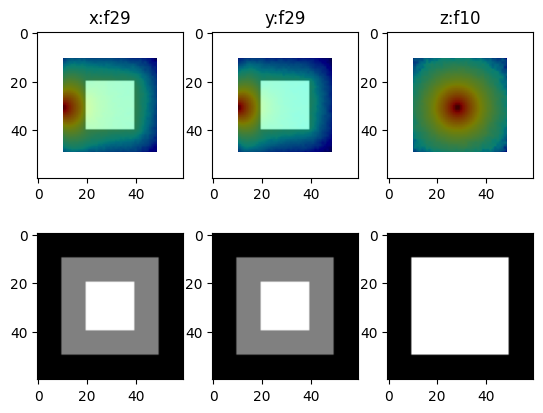

C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:38: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:39: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:43: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:44: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet",alpha=0.5)
C:\Users\liushiyu0523\AppData\Local\Temp\ipykernel_19728\414961570.py:48: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :

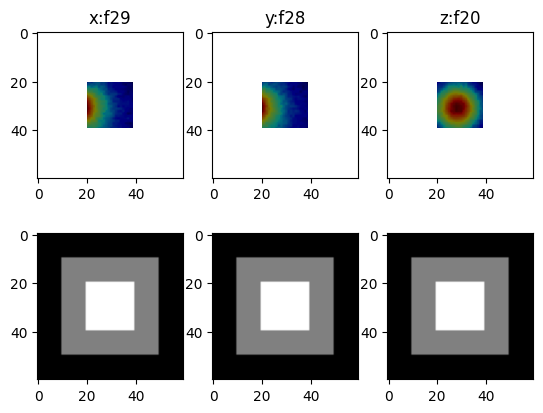

In [64]:
# QUICK TEST
first_prop=[0.019, 14.6, 0.89, 1.37] # scalf
second_prop=[0.0144, 0.09, 0.89, 1.37]
cfg={}
cfg['nphoton']=1e6
cfg['vol']=np.zeros([60, 60, 60], dtype='uint8')
cfg['vol'][10:50, 10:50, 10:50]=1
cfg['vol'][20:40, 20:40, 20:40]=2
cfg['tstart']=0
cfg['tend']=5e-9
cfg['tstep']=5e-9
cfg['srcpos']=[30,30,0]
cfg['srcdir']=[0,0,1]
cfg['prop']=[[0, 0, 1, 1], first_prop, second_prop]

res=pmcx.run(cfg)
view_result(res,cfg["vol"])
view_result_mask(res,cfg["vol"],mask=(cfg["vol"]==2))